In [33]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [6]:
import os
import glob
import numpy as np
import awkward as ak
import uproot
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


In [7]:

device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print(f"Using device: {device}")

Using device: mps


In [8]:
train_directory = "~/Desktop/DoubleB/train_data/"
test_directory = "~/Desktop/DoubleB/test_data/"


In [9]:
MAX_PF = 100
MAX_TRACK = 60
MAX_SV = 10# Global Jet Features
jet_features = [
    'fj_eta', 'fj_phi', 'fj_mass',
    'fj_tau1', 'fj_tau2', 'fj_tau3', 'fj_tau21', 'fj_tau32',
    'fj_ptDR', 'fj_relptdiff', 'fj_sdn2', 'fj_z_ratio', 'fj_nSV', 'fj_jetNTracks',
    'fj_trackSipdSig_0', 'fj_trackSipdSig_1', 'fj_trackSipdSig_2', 'fj_trackSipdSig_3',
    'fj_trackSipdSig_0_0', 'fj_trackSipdSig_0_1', 'fj_trackSipdSig_1_0', 'fj_trackSipdSig_1_1',
    'fj_trackSip2dSigAboveCharm_0', 'fj_trackSip2dSigAboveBottom_0', 'fj_trackSip2dSigAboveBottom_1',
    'fj_tau0_trackEtaRel_0', 'fj_tau0_trackEtaRel_1', 'fj_tau0_trackEtaRel_2',
    'fj_tau1_trackEtaRel_0', 'fj_tau1_trackEtaRel_1', 'fj_tau1_trackEtaRel_2',
    'fj_tau_vertexMass_0', 'fj_tau_vertexMass_1', 'fj_tau_vertexEnergyRatio_0', 
    'fj_tau_vertexEnergyRatio_1', 'fj_tau_flightDistance2dSig_0', 'fj_tau_flightDistance2dSig_1',
    'fj_tau_vertexDeltaR_0'
]

# PF Candidate Features
pf_features = [
    'pfcand_ptrel', 'pfcand_erel', 'pfcand_phirel', 'pfcand_etarel', 'pfcand_deltaR', 
    'pfcand_drminsv', 'pfcand_drsubjet1', 'pfcand_drsubjet2', 'pfcand_dz', 'pfcand_dzsig', 
    'pfcand_dxy', 'pfcand_dxysig', 'pfcand_fromPV', 'pfcand_VTX_ass', 'pfcand_lostInnerHits', 
    'pfcand_puppiw', 'pfcand_hcalFrac', 'pfcand_charge', 'pfcand_isChargedHad', 
    'pfcand_isNeutralHad', 'pfcand_isGamma', 'pfcand_isEl', 'pfcand_isMu', 'pfcand_mass'
]

# Track Features
track_features = [
    'trackBTag_DeltaR', 'trackBTag_Eta', 'trackBTag_EtaRel', 
    'trackBTag_JetDistVal', 'trackBTag_Momentum'
]

# SV Features (Commonly used in DeepDoubleB/ParticleNet)
sv_features = [
    'sv_pt', 'sv_deltaR', 'sv_mass', 'sv_ntracks', 'sv_chi2', 'sv_normchi2', 
    'sv_dxy', 'sv_dxysig', 'sv_d3d', 'sv_d3dsig', 'sv_costhetasvpv'
]


In [10]:
spectators = ['fj_sdmass', 'fj_pt', 'fj_doubleb']


In [11]:
def pad_sequence(array, max_len):
    """Pads or truncates an awkward array sequence to a fixed length."""
    return ak.fill_none(ak.pad_none(array, max_len, clip=True), 0)



import gc

def load_data(directory, max_files=None):
    files = sorted(glob.glob(os.path.expanduser(directory) + "*.root"))
    if max_files:
        files = files[:max_files]

    # Storage lists
    jet_list, pf_list, trk_list, sv_list, label_list = [], [], [], [], []
    pt_list, mass_list, db_list = [], [], []

    print(f"Starting to load {len(files)} files...")

    for f in files:
        if "merged_63.root" in f: continue
            
        print(f"Reading: {os.path.basename(f)}...", end=" ", flush=True)
        try:
            with uproot.open(f) as file_handle:
                tree = file_handle["deepntuplizer/tree"]
                
                # Define all branches needed
                branches = (jet_features + pf_features + track_features + 
                           sv_features + spectators +
                           ['sample_isQCD', 'fj_isQCD', 'fj_isH', 'fj_isBB'])
                
                data = tree.arrays(branches, library='ak')

                # Filtering logic
                mask = (data['fj_sdmass'] > 40) & (data['fj_sdmass'] < 200) & \
                       (data['fj_pt'] > 350) & (data['fj_pt'] < 2000)
                
                label_hbb = (data['fj_isH'] == 1) & (data['fj_isBB'] == 1)
                label_qcd = (data['fj_isQCD'] == 1) & (data['sample_isQCD'] == 1)
                valid = mask & (label_qcd | label_hbb)
                
                filtered = data[valid]
                if len(filtered) == 0:
                    print("Skipped (no valid jets).")
                    continue

                # 1. Training Labels & Features (float32)
                y = ak.where(label_hbb[valid], 1, 0).to_numpy().astype(np.float32)
                jets_np = np.stack([ak.to_numpy(filtered[f]) for f in jet_features], axis=-1).astype(np.float32)
                
                # 2. Spectators (for evaluation)
                pt_list.append(ak.to_numpy(filtered['fj_pt']).astype(np.float32))
                mass_list.append(ak.to_numpy(filtered['fj_sdmass']).astype(np.float32))
                db_list.append(ak.to_numpy(filtered['fj_doubleb']).astype(np.float32))

                # 3. Padded Sequences (PF, Tracks, SV)
                pf_p = ak.fill_none(ak.pad_none(filtered[pf_features], 100, axis=1, clip=True), 0)
                pfs_np = np.stack([ak.to_numpy(pf_p[f]) for f in pf_features], axis=-1).astype(np.float32)

                trk_p = ak.fill_none(ak.pad_none(filtered[track_features], 60, axis=1, clip=True), 0)
                trks_np = np.stack([ak.to_numpy(trk_p[f]) for f in track_features], axis=-1).astype(np.float32)

                sv_p = ak.fill_none(ak.pad_none(filtered[sv_features], 10, axis=1, clip=True), 0)
                svs_np = np.stack([ak.to_numpy(sv_p[f]) for f in sv_features], axis=-1).astype(np.float32)

                # Append to main lists
                jet_list.append(jets_np); pf_list.append(pfs_np)
                trk_list.append(trks_np); sv_list.append(svs_np)
                label_list.append(y)
                
                print(f"Done ({len(y)} jets)")
                
                # Cleanup memory per file
                del data, filtered, pf_p, trk_p, sv_p
                gc.collect() 
                    
        except Exception as e:
            print(f"FAILED. Skipping file. Error: {str(e)[:50]}...")
            continue

    return (np.concatenate(jet_list), np.concatenate(pf_list), 
            np.concatenate(trk_list), np.concatenate(sv_list), 
            np.concatenate(label_list), np.concatenate(pt_list), 
            np.concatenate(mass_list), np.concatenate(db_list))

In [12]:
class ParticleDataset(Dataset):
    def __init__(self, jets, pfs, tracks, svs, labels, pt, mass, db):
        self.jets = torch.from_numpy(jets)
        self.pfs = torch.from_numpy(pfs)
        self.tracks = torch.from_numpy(tracks)
        self.svs = torch.from_numpy(svs)
        self.labels = torch.from_numpy(labels)
        self.pt = torch.from_numpy(pt)
        self.mass = torch.from_numpy(mass)
        self.db = torch.from_numpy(db)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (self.pfs[idx], self.tracks[idx], self.svs[idx], 
                self.jets[idx], self.labels[idx], 
                self.pt[idx], self.mass[idx], self.db[idx])

In [13]:
import torch.nn as nn
import torch

class MultiInputDNN(nn.Module):
    def __init__(self, pf_dim, tk_dim, sv_dim, jet_dim, hidden_dim=256):
        super().__init__()
        
        # Encoders for sequences (Flatten sequence dimension)
        self.pf_flat_dim = 100 * pf_dim
        self.tk_flat_dim = 60 * tk_dim
        self.sv_flat_dim = 10 * sv_dim
        
        total_input_dim = self.pf_flat_dim + self.tk_flat_dim + self.sv_flat_dim + jet_dim

        self.classifier = nn.Sequential(
            nn.Linear(total_input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim), # Added for stability
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim), # Keeps the math from "exploding"
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, pfs, tracks, svs, jets):
        # 1. Flatten the sequences
        pfs_flat = pfs.view(pfs.size(0), -1)
        tracks_flat = tracks.view(tracks.size(0), -1)
        svs_flat = svs.view(svs.size(0), -1)
        
        # 2. Concatenate
        combined = torch.cat([pfs_flat, tracks_flat, svs_flat, jets], dim=-1)
        
        # 3. Pass through the DNN
        return self.classifier(combined).squeeze()

In [14]:
def train(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    batch_losses = [] 
    
    for i, (pfs, tks, svs, jets, y, pt, mass, db) in enumerate(loader):
        pfs, tks, svs, jets, y = pfs.to(device), tks.to(device), svs.to(device), jets.to(device), y.to(device)
        
        optimizer.zero_grad()
        out = model(pfs, tks, svs, jets)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        
        loss_val = loss.item()
        total_loss += loss_val
        batch_losses.append(loss_val) 
        
        if i % 100 == 0:
            print(f"Batch {i}/{len(loader)} | Loss: {loss_val:.4f}")
            
    avg_epoch_loss = total_loss / len(loader)
    return avg_epoch_loss, batch_losses


In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def evaluate(model, loader, device, output_folder="plots_output"): 
    if not os.path.exists(output_folder): 
        os.makedirs(output_folder) 

    model.eval() 
    y_true, y_score, pt_vals, mass_vals, db_vals = [], [], [], [], [] 
    
    with torch.no_grad(): 
        for pfs, tks, svs, jets, y, pt, mass, db in loader: 
            pfs, tks, svs, jets, y = pfs.to(device), tks.to(device), svs.to(device), jets.to(device), y.to(device) 
            out = model(pfs, tks, svs, jets) 
            y_score.extend(out.cpu().numpy()) 
            y_true.extend(y.cpu().numpy()) 
            pt_vals.extend(pt.numpy()) 
            mass_vals.extend(mass.numpy()) 
            db_vals.extend(db.numpy()) 

    y_true, y_score = np.array(y_true), np.array(y_score) 
    pt_vals, mass_vals, db_vals = np.array(pt_vals), np.array(mass_vals), np.array(db_vals) 

    def style_plot(title): 
        plt.grid(True, linestyle='--', alpha=0.6) 
        plt.xlabel('Tagging efficiency ($H \\rightarrow b\\bar{b}$)', fontsize=12) 
        plt.ylabel('1 $-$ mistagging efficiency ($g \\rightarrow b\\bar{b}$)', fontsize=12) 
        plt.title(title, loc='left', fontsize=14) 
        plt.title('$\sqrt{s} = 13$ TeV', loc='right', fontsize=10, color='grey') 
        plt.legend(loc="lower left", frameon=False) 
        plt.tight_layout() 

    # Calculate Overall FPR/TPR once for reference
    fpr_all, tpr_all, _ = roc_curve(y_true, y_score)
    auc_all = auc(fpr_all, tpr_all)

    # --- FIGURE 1: pT Bins + Overall --- 
    plt.figure(figsize=(7, 6)) 
    plt.plot(tpr_all, 1-fpr_all, label=f'Overall (AUC: {auc_all:.3f})', color='black', linestyle='--', linewidth=1.5)
    for (low, high) in [(350, 600), (600, 800), (800, 2000)]: 
        m = (pt_vals >= low) & (pt_vals < high) 
        if np.sum(m) > 10: 
            fpr, tpr, _ = roc_curve(y_true[m], y_score[m]) 
            plt.plot(tpr, 1-fpr, label=f'{low} < $p_T$ < {high} GeV (AUC: {auc(fpr, tpr):.3f})') 
    style_plot('Performance by $p_T$ Bin') 
    plt.savefig(f'{output_folder}/pt_bins_roc.png', dpi=300) 
    plt.show() 

    # --- FIGURE 2: Mass Bins (4 Divisions) + Overall --- 
    plt.figure(figsize=(7, 6)) 
    plt.plot(tpr_all, 1-fpr_all, label=f'Overall (AUC: {auc_all:.3f})', color='black', linestyle='--', linewidth=1.5)
    for (low, high) in [(40, 80), (80, 120), (120, 160), (160, 200)]: 
        m = (mass_vals >= low) & (mass_vals < high) 
        if np.sum(m) > 10: 
            fpr, tpr, _ = roc_curve(y_true[m], y_score[m]) 
            plt.plot(tpr, 1-fpr, label=f'{low} < $m_{{SD}}$ < {high} GeV (AUC: {auc(fpr, tpr):.3f})') 
    style_plot('Performance by $m_{SD}$ Bin') 
    plt.savefig(f'{output_folder}/sdmass_bins_roc.png', dpi=300) 
    plt.show() 

    # --- FIGURE 3: Normalized Confusion Matrix (Percentages) ---
    plt.figure(figsize=(6, 5))
    y_pred = (y_score > 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    
    # Normalize by row (true labels)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap='Blues', 
                xticklabels=['Background', 'Higgs'], 
                yticklabels=['Background', 'Higgs'])
    plt.title('Normalized Confusion Matrix (Efficiencies)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig(f'{output_folder}/confusion_matrix_norm.png', dpi=300)
    plt.show()

    # --- FIGURE 4: Absolute Confusion Matrix (Raw Counts) ---
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap='Greens', 
                xticklabels=['Background', 'Higgs'], 
                yticklabels=['Background', 'Higgs'])
    plt.title('Absolute Confusion Matrix (Raw Counts)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig(f'{output_folder}/confusion_matrix_absolute.png', dpi=300)
    plt.show()

    # --- FIGURE 3: Confusion Matrix ---
    plt.figure(figsize=(6, 5))
    # Using 0.5 as threshold for classification
    y_pred = (y_score > 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    # Normalize by row (true labels) to show recall/efficiencies
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap='Blues', 
                xticklabels=['Background', 'Higgs'], 
                yticklabels=['Background', 'Higgs'])
    plt.title('Normalized Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig(f'{output_folder}/confusion_matrix.png', dpi=300)
    plt.show()

    print(f"Evaluation complete. Overall AUC: {auc_all:.4f}")

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# Assume 'losses' is the list returned by the train function
# avg_loss, losses = train(model, train_loader, optimizer, criterion, device)

def plot_loss(batch_losses):b
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.figure(figsize=(10, 5))
    
    # Plot raw batch losses (the bouncy blue light line)
    plt.plot(batch_losses, alpha=0.3, color='dodgerblue', label='Batch Loss')
    
    # Plot moving average (the smooth red trend line)
    # We use a window of 50 batches to see the trend
    smooth_loss = pd.Series(batch_losses).rolling(window=50).mean()
    plt.plot(smooth_loss, color='crimson', linewidth=2, label='Moving Average (50 batches)')
    
    plt.title('Training Loss: Epoch 1', fontsize=15)
    plt.xlabel('Batch Number', fontsize=12)
    plt.ylabel('BCE Loss', fontsize=12)
    plt.legend()
    plt.ylim(0, 0.5) # Focus on the interesting range (0.0 to 0.5)
    
    plt.savefig("loss_plot_epoch1.png")
    plt.show()


IndentationError: unexpected indent (105790616.py, line 8)

In [27]:

# 1. Load data (Now returns 8 items)
print("Loading Training Data...")
train_out = load_data(train_directory, max_files=79)
(train_jets, train_pfs, train_trks, train_svs, 
 train_labels, train_pt, train_mass, train_db) = train_out

print("\nLoading Testing Data...")
test_out = load_data(test_directory, max_files=10)
(test_jets, test_pfs, test_trks, test_svs, 
 test_labels, test_pt, test_mass, test_db) = test_out

# 2. Create PyTorch Datasets (Ensure you pass all 8 variables)
train_dataset = ParticleDataset(
    train_jets, train_pfs, train_trks, train_svs, 
    train_labels, train_pt, train_mass, train_db
)

test_dataset = ParticleDataset(
    test_jets, test_pfs, test_trks, test_svs, 
    test_labels, test_pt, test_mass, test_db
)

# 3. Create DataLoaders
# Reduced batch_size to 64 for better stability on Mac
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"\nSuccessfully loaded {len(train_dataset)} training jets and {len(test_dataset)} testing jets.")

Loading Training Data...
Starting to load 79 files...
Reading: ntuple_merged_10.root... Done (57422 jets)
Reading: ntuple_merged_11.root... Done (57663 jets)
Reading: ntuple_merged_12.root... Done (57717 jets)
Reading: ntuple_merged_13.root... Done (57255 jets)
Reading: ntuple_merged_14.root... Done (57785 jets)
Reading: ntuple_merged_15.root... Done (57759 jets)
Reading: ntuple_merged_16.root... Done (57589 jets)
Reading: ntuple_merged_17.root... Done (57712 jets)
Reading: ntuple_merged_18.root... Done (57627 jets)
Reading: ntuple_merged_19.root... Done (57347 jets)
Reading: ntuple_merged_20.root... Done (57165 jets)
Reading: ntuple_merged_21.root... Done (57584 jets)
Reading: ntuple_merged_22.root... FAILED. Skipping file. Error: expected Chunk of length 139,
received 0 bytes fro...
Reading: ntuple_merged_23.root... Done (57847 jets)
Reading: ntuple_merged_24.root... Done (57615 jets)
Reading: ntuple_merged_25.root... Done (57580 jets)
Reading: ntuple_merged_26.root... Done (57564 je

In [14]:
# 1. Determine dimensions (jet_features is now shorter since we moved doubleb)
pf_in_dim = len(pf_features)
jet_in_dim = len(jet_features)
tk_in_dim = len(track_features)
sv_in_dim = len(sv_features)

# 2. Initialize Model
model = MultiInputDNN(
    pf_dim=pf_in_dim, 
    tk_dim=tk_in_dim, 
    sv_dim=sv_in_dim, 
    jet_dim=jet_in_dim
).to(device)

# 3. Setup Optimizer and Loss
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
criterion = nn.BCELoss()

# 4. Training Loop
for epoch in range(1, 11):
    # This call now works because your updated 'train' function 
    # handles the 8 items from train_loader
    avg_loss = train(model, train_loader, optimizer, criterion, device)
    


Batch 0/66565 | Loss: 0.7295
Batch 50/66565 | Loss: 0.4168
Batch 100/66565 | Loss: 0.5120
Batch 150/66565 | Loss: 0.2600
Batch 200/66565 | Loss: 0.4026
Batch 250/66565 | Loss: 0.2536
Batch 300/66565 | Loss: 0.3900
Batch 350/66565 | Loss: 0.3383
Batch 400/66565 | Loss: 0.2485
Batch 450/66565 | Loss: 0.2767
Batch 500/66565 | Loss: 0.1961
Batch 550/66565 | Loss: 0.2832
Batch 600/66565 | Loss: 0.3299
Batch 650/66565 | Loss: 0.2934
Batch 700/66565 | Loss: 0.3707
Batch 750/66565 | Loss: 0.3132
Batch 800/66565 | Loss: 0.4130
Batch 850/66565 | Loss: 0.2482
Batch 900/66565 | Loss: 0.1947
Batch 950/66565 | Loss: 0.1470
Batch 1000/66565 | Loss: 0.2093
Batch 1050/66565 | Loss: 0.2929
Batch 1100/66565 | Loss: 0.2294
Batch 1150/66565 | Loss: 0.2325
Batch 1200/66565 | Loss: 0.2443
Batch 1250/66565 | Loss: 0.2318
Batch 1300/66565 | Loss: 0.2437
Batch 1350/66565 | Loss: 0.2419
Batch 1400/66565 | Loss: 0.3302
Batch 1450/66565 | Loss: 0.2748
Batch 1500/66565 | Loss: 0.2583
Batch 1550/66565 | Loss: 0.3723

KeyboardInterrupt: 

In [15]:
torch.save(model.state_dict(), 'higgs_tagger_epoch1.pth')
print("Model saved! You can now close the laptop if needed.")

Model saved! You can now close the laptop if needed.


In [ ]:
# Simply call the train function again for the next epoch
print("Starting Epoch 2...")
avg_loss_e2 = train(model, train_loader, optimizer, criterion, device)
print(f"Epoch 2 Complete | Average Loss: {avg_loss_e2:.4f}")



Starting Epoch 2...
Batch 0/66565 | Loss: 0.2756
Batch 100/66565 | Loss: 0.1124
Batch 200/66565 | Loss: 0.1351
Batch 300/66565 | Loss: 0.2767
Batch 400/66565 | Loss: 0.2124
Batch 500/66565 | Loss: 0.2653
Batch 600/66565 | Loss: 0.2196
Batch 700/66565 | Loss: 0.1902
Batch 800/66565 | Loss: 0.1327
Batch 900/66565 | Loss: 0.3848
Batch 1000/66565 | Loss: 0.3151
Batch 1100/66565 | Loss: 0.1450
Batch 1200/66565 | Loss: 0.0779
Batch 1300/66565 | Loss: 0.2067
Batch 1400/66565 | Loss: 0.1731
Batch 1500/66565 | Loss: 0.1605
Batch 1600/66565 | Loss: 0.2589
Batch 1700/66565 | Loss: 0.1342
Batch 1800/66565 | Loss: 0.1795
Batch 1900/66565 | Loss: 0.1641
Batch 2000/66565 | Loss: 0.1837
Batch 2100/66565 | Loss: 0.2121
Batch 2200/66565 | Loss: 0.1532
Batch 2300/66565 | Loss: 0.1064
Batch 2400/66565 | Loss: 0.1605
Batch 2500/66565 | Loss: 0.2171
Batch 2600/66565 | Loss: 0.1071
Batch 2700/66565 | Loss: 0.2925
Batch 2800/66565 | Loss: 0.1292
Batch 2900/66565 | Loss: 0.3648
Batch 3000/66565 | Loss: 0.3110


In [29]:
# Save the new version
torch.save(model.state_dict(), 'higgs_tagger_epoch3.pth')

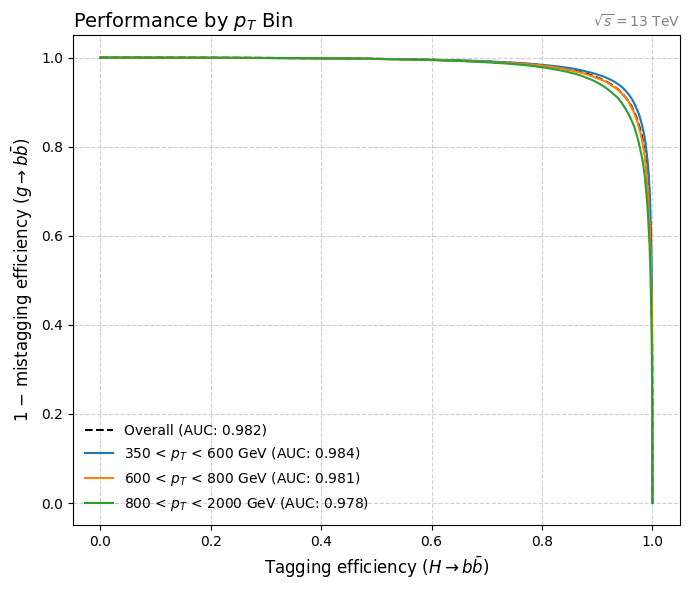

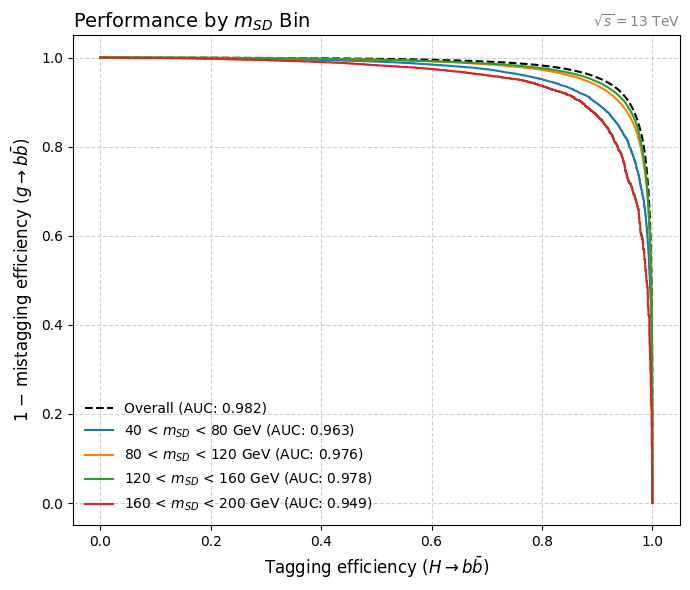

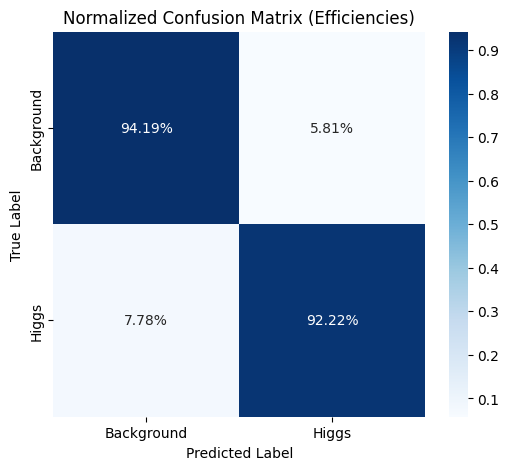

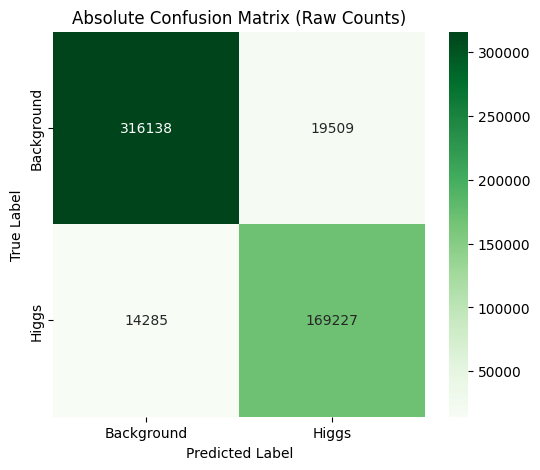

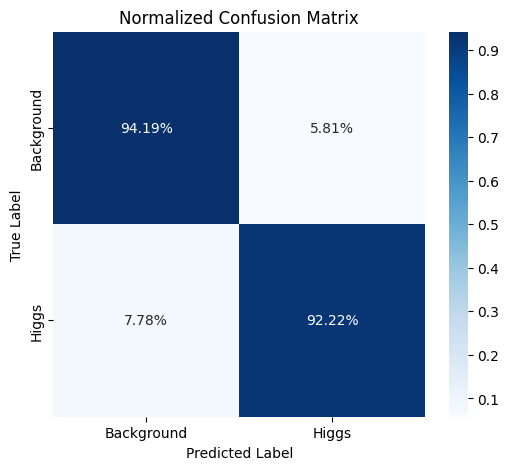

Evaluation complete. Overall AUC: 0.9818


In [37]:
# 5. Final Performance Plot
# Note: Use 'evaluate_full' to get the pT bins and Double-B comparison plots
evaluate(model, test_loader, device, output_folder="Final_Results")

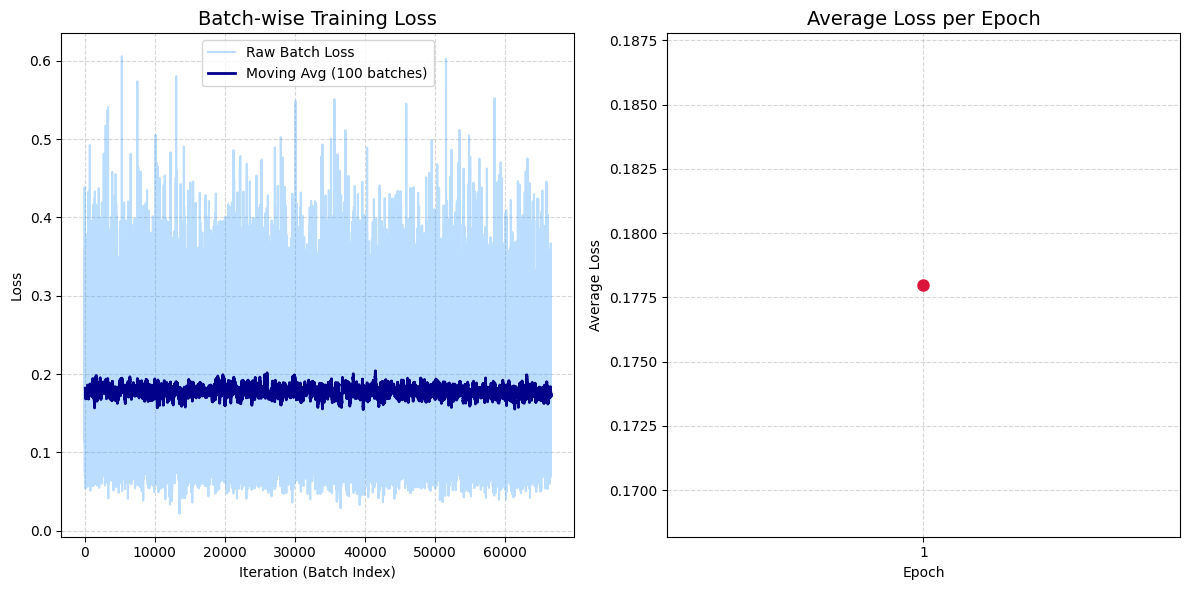

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_training_results(batch_losses, epoch_averages):
    plt.figure(figsize=(12, 6))
    
    # --- Plot 1: Batch Loss (The detailed view) ---
    plt.subplot(1, 2, 1)
    # Plot raw data with low alpha (transparency)
    plt.plot(batch_losses, color='dodgerblue', alpha=0.3, label='Raw Batch Loss')
    
    # Calculate and plot moving average to show the trend
    window = 100
    if len(batch_losses) > window:
        smooth_loss = pd.Series(batch_losses).rolling(window=window).mean()
        plt.plot(smooth_loss, color='darkblue', linewidth=2, label=f'Moving Avg ({window} batches)')
    
    plt.title('Batch-wise Training Loss', fontsize=14)
    plt.xlabel('Iteration (Batch Index)')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()

    # --- Plot 2: Epoch Average (The big picture) ---
    plt.subplot(1, 2, 2)
    epochs = np.arange(1, len(epoch_averages) + 1)
    plt.plot(epochs, epoch_averages, marker='o', color='crimson', linewidth=2, markersize=8)
    
    plt.title('Average Loss per Epoch', fontsize=14)
    plt.xlabel('Epoch')
    plt.ylabel('Average Loss')
    plt.xticks(epochs) # Ensure we only show integer epoch numbers
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=300)
    plt.show()

# Call the function
plot_training_results(all_batch_history, epoch_averages)

In [27]:
# Initialize the storage lists
all_batch_history = []
epoch_averages = []

In [28]:
for epoch in range(1, 3): # Or whatever range you are running
    print(f"Starting Epoch {epoch}...")
    
    # Capture the two outputs from your train function
    avg_val, batch_vals = train(model, train_loader, optimizer, criterion, device)
    
    # Store them in the lists we just initialized
    epoch_averages.append(avg_val)
    all_batch_history.extend(batch_vals) # .extend adds the list of batch losses to our big list

Starting Epoch 1...
Batch 0/66565 | Loss: 0.1988
Batch 100/66565 | Loss: 0.0647
Batch 200/66565 | Loss: 0.2507
Batch 300/66565 | Loss: 0.1727
Batch 400/66565 | Loss: 0.1744
Batch 500/66565 | Loss: 0.1917
Batch 600/66565 | Loss: 0.1913
Batch 700/66565 | Loss: 0.2020
Batch 800/66565 | Loss: 0.2118
Batch 900/66565 | Loss: 0.1092
Batch 1000/66565 | Loss: 0.1158
Batch 1100/66565 | Loss: 0.3009
Batch 1200/66565 | Loss: 0.1827
Batch 1300/66565 | Loss: 0.1560
Batch 1400/66565 | Loss: 0.0950
Batch 1500/66565 | Loss: 0.1733
Batch 1600/66565 | Loss: 0.2496
Batch 1700/66565 | Loss: 0.2234
Batch 1800/66565 | Loss: 0.1281
Batch 1900/66565 | Loss: 0.1196
Batch 2000/66565 | Loss: 0.1721
Batch 2100/66565 | Loss: 0.0996
Batch 2200/66565 | Loss: 0.1938
Batch 2300/66565 | Loss: 0.1892
Batch 2400/66565 | Loss: 0.0876
Batch 2500/66565 | Loss: 0.1623
Batch 2600/66565 | Loss: 0.1616
Batch 2700/66565 | Loss: 0.1713
Batch 2800/66565 | Loss: 0.1696
Batch 2900/66565 | Loss: 0.0680
Batch 3000/66565 | Loss: 0.1987


KeyboardInterrupt: 

In [43]:
import re
import matplotlib.pyplot as plt
import numpy as np

# --- PASTE YOUR LOGS HERE ---
logs = {
    1: """
Batch 0/66565 | Loss: 0.7295
Batch 50/66565 | Loss: 0.4168
Batch 100/66565 | Loss: 0.5120
Batch 150/66565 | Loss: 0.2600
Batch 200/66565 | Loss: 0.4026
Batch 250/66565 | Loss: 0.2536
Batch 300/66565 | Loss: 0.3900
Batch 350/66565 | Loss: 0.3383
Batch 400/66565 | Loss: 0.2485
Batch 450/66565 | Loss: 0.2767
Batch 500/66565 | Loss: 0.1961
Batch 550/66565 | Loss: 0.2832
Batch 600/66565 | Loss: 0.3299
Batch 650/66565 | Loss: 0.2934
Batch 700/66565 | Loss: 0.3707
Batch 750/66565 | Loss: 0.3132
Batch 800/66565 | Loss: 0.4130
Batch 850/66565 | Loss: 0.2482
Batch 900/66565 | Loss: 0.1947
Batch 950/66565 | Loss: 0.1470
Batch 1000/66565 | Loss: 0.2093
Batch 1050/66565 | Loss: 0.2929
Batch 1100/66565 | Loss: 0.2294
Batch 1150/66565 | Loss: 0.2325
Batch 1200/66565 | Loss: 0.2443
Batch 1250/66565 | Loss: 0.2318
Batch 1300/66565 | Loss: 0.2437
Batch 1350/66565 | Loss: 0.2419
Batch 1400/66565 | Loss: 0.3302
Batch 1450/66565 | Loss: 0.2748
Batch 1500/66565 | Loss: 0.2583
Batch 1550/66565 | Loss: 0.3723
Batch 1600/66565 | Loss: 0.1752
Batch 1650/66565 | Loss: 0.3269
Batch 1700/66565 | Loss: 0.2107
Batch 1750/66565 | Loss: 0.2209
Batch 1800/66565 | Loss: 0.2114
Batch 1850/66565 | Loss: 0.1837
Batch 1900/66565 | Loss: 0.2738
Batch 1950/66565 | Loss: 0.2629
Batch 2000/66565 | Loss: 0.2098
Batch 2050/66565 | Loss: 0.4378
Batch 2100/66565 | Loss: 0.1619
Batch 2150/66565 | Loss: 0.2704
Batch 2200/66565 | Loss: 0.2871
Batch 2250/66565 | Loss: 0.1627
Batch 2300/66565 | Loss: 0.2893
Batch 2350/66565 | Loss: 0.1934
Batch 2400/66565 | Loss: 0.2424
Batch 2450/66565 | Loss: 0.4581
Batch 2500/66565 | Loss: 0.1872
Batch 2550/66565 | Loss: 0.1376
Batch 2600/66565 | Loss: 0.2058
Batch 2650/66565 | Loss: 0.3527
Batch 2700/66565 | Loss: 0.2379
Batch 2750/66565 | Loss: 0.2412
Batch 2800/66565 | Loss: 0.3652
Batch 2850/66565 | Loss: 0.3747
Batch 2900/66565 | Loss: 0.1615
Batch 2950/66565 | Loss: 0.2998
Batch 3000/66565 | Loss: 0.2615
Batch 3050/66565 | Loss: 0.1936
Batch 3100/66565 | Loss: 0.1812
Batch 3150/66565 | Loss: 0.2354
Batch 3200/66565 | Loss: 0.1353
Batch 3250/66565 | Loss: 0.1846
Batch 3300/66565 | Loss: 0.2245
Batch 3350/66565 | Loss: 0.2163
Batch 3400/66565 | Loss: 0.2684
Batch 3450/66565 | Loss: 0.2859
Batch 3500/66565 | Loss: 0.2449
Batch 3550/66565 | Loss: 0.3247
Batch 3600/66565 | Loss: 0.2383
Batch 3650/66565 | Loss: 0.2721
Batch 3700/66565 | Loss: 0.2555
Batch 3750/66565 | Loss: 0.1547
Batch 3800/66565 | Loss: 0.2105
Batch 3850/66565 | Loss: 0.1655
Batch 3900/66565 | Loss: 0.2825
Batch 3950/66565 | Loss: 0.3039
Batch 4000/66565 | Loss: 0.1433
Batch 4050/66565 | Loss: 0.2237
Batch 4100/66565 | Loss: 0.2015
Batch 4150/66565 | Loss: 0.1418
Batch 4200/66565 | Loss: 0.2179
Batch 4250/66565 | Loss: 0.3514
Batch 4300/66565 | Loss: 0.2305
Batch 4350/66565 | Loss: 0.2106
Batch 4400/66565 | Loss: 0.3399
Batch 4450/66565 | Loss: 0.1115
Batch 4500/66565 | Loss: 0.1299
Batch 4550/66565 | Loss: 0.2783
Batch 4600/66565 | Loss: 0.2928
Batch 4650/66565 | Loss: 0.2512
Batch 4700/66565 | Loss: 0.1864
Batch 4750/66565 | Loss: 0.3027
Batch 4800/66565 | Loss: 0.2190
Batch 4850/66565 | Loss: 0.2593
Batch 4900/66565 | Loss: 0.3265
Batch 4950/66565 | Loss: 0.3563
Batch 5000/66565 | Loss: 0.1788
Batch 5050/66565 | Loss: 0.2001
Batch 5100/66565 | Loss: 0.2370
Batch 5150/66565 | Loss: 0.3092
Batch 5200/66565 | Loss: 0.2767
Batch 5250/66565 | Loss: 0.2878
Batch 5300/66565 | Loss: 0.2357
Batch 5350/66565 | Loss: 0.2618
Batch 5400/66565 | Loss: 0.2830
Batch 5450/66565 | Loss: 0.1312
Batch 5500/66565 | Loss: 0.1367
Batch 5550/66565 | Loss: 0.1818
Batch 5600/66565 | Loss: 0.1880
Batch 5650/66565 | Loss: 0.3183
Batch 5700/66565 | Loss: 0.3210
Batch 5750/66565 | Loss: 0.1266
Batch 5800/66565 | Loss: 0.1301
Batch 5850/66565 | Loss: 0.2291
Batch 5900/66565 | Loss: 0.2195
Batch 5950/66565 | Loss: 0.1989
Batch 6000/66565 | Loss: 0.2808
Batch 6050/66565 | Loss: 0.1992
Batch 6100/66565 | Loss: 0.2041
Batch 6150/66565 | Loss: 0.1784
Batch 6200/66565 | Loss: 0.2482
Batch 6250/66565 | Loss: 0.1799
Batch 6300/66565 | Loss: 0.2279
Batch 6350/66565 | Loss: 0.2872
Batch 6400/66565 | Loss: 0.1688
Batch 6450/66565 | Loss: 0.3509
Batch 6500/66565 | Loss: 0.3041
Batch 6550/66565 | Loss: 0.3374
Batch 6600/66565 | Loss: 0.1616
Batch 6650/66565 | Loss: 0.2184
Batch 6700/66565 | Loss: 0.2115
Batch 6750/66565 | Loss: 0.1876
Batch 6800/66565 | Loss: 0.1455
Batch 6850/66565 | Loss: 0.1429
Batch 6900/66565 | Loss: 0.1374
Batch 6950/66565 | Loss: 0.1855
Batch 7000/66565 | Loss: 0.1427
Batch 7050/66565 | Loss: 0.3904
Batch 7100/66565 | Loss: 0.1939
Batch 7150/66565 | Loss: 0.3242
Batch 7200/66565 | Loss: 0.2521
Batch 7250/66565 | Loss: 0.2061
Batch 7300/66565 | Loss: 0.3195
Batch 7350/66565 | Loss: 0.3251
Batch 7400/66565 | Loss: 0.2382
Batch 7450/66565 | Loss: 0.2532
Batch 7500/66565 | Loss: 0.2229
Batch 7550/66565 | Loss: 0.2950
Batch 7600/66565 | Loss: 0.4029
Batch 7650/66565 | Loss: 0.2444
Batch 7700/66565 | Loss: 0.3272
Batch 7750/66565 | Loss: 0.1956
Batch 7800/66565 | Loss: 0.4142
Batch 7850/66565 | Loss: 0.1788
Batch 7900/66565 | Loss: 0.1832
Batch 7950/66565 | Loss: 0.1149
Batch 8000/66565 | Loss: 0.1843
Batch 8050/66565 | Loss: 0.3419
Batch 8100/66565 | Loss: 0.2415
Batch 8150/66565 | Loss: 0.2126
Batch 8200/66565 | Loss: 0.3302
Batch 8250/66565 | Loss: 0.1688
Batch 8300/66565 | Loss: 0.3769
Batch 8350/66565 | Loss: 0.2685
Batch 8400/66565 | Loss: 0.2587
Batch 8450/66565 | Loss: 0.1716
Batch 8500/66565 | Loss: 0.1911
Batch 8550/66565 | Loss: 0.1790
Batch 8600/66565 | Loss: 0.1348
Batch 8650/66565 | Loss: 0.4057
Batch 8700/66565 | Loss: 0.2483
Batch 8750/66565 | Loss: 0.3029
Batch 8800/66565 | Loss: 0.2873
Batch 8850/66565 | Loss: 0.1756
Batch 8900/66565 | Loss: 0.2412
Batch 8950/66565 | Loss: 0.1866
Batch 9000/66565 | Loss: 0.3264
Batch 9050/66565 | Loss: 0.2366
Batch 9100/66565 | Loss: 0.1828
Batch 9150/66565 | Loss: 0.1558
Batch 9200/66565 | Loss: 0.1806
Batch 9250/66565 | Loss: 0.3206
Batch 9300/66565 | Loss: 0.1023
Batch 9350/66565 | Loss: 0.1607
Batch 9400/66565 | Loss: 0.2114
Batch 9450/66565 | Loss: 0.2310
Batch 9500/66565 | Loss: 0.1415
Batch 9550/66565 | Loss: 0.2877
Batch 9600/66565 | Loss: 0.1997
Batch 9650/66565 | Loss: 0.2084
Batch 9700/66565 | Loss: 0.2044
Batch 9750/66565 | Loss: 0.2737
Batch 9800/66565 | Loss: 0.1052
Batch 9850/66565 | Loss: 0.2556
Batch 9900/66565 | Loss: 0.2520
Batch 9950/66565 | Loss: 0.1937
Batch 10000/66565 | Loss: 0.4648
Batch 10050/66565 | Loss: 0.2022
Batch 10100/66565 | Loss: 0.2068
Batch 10150/66565 | Loss: 0.1160
Batch 10200/66565 | Loss: 0.2759
Batch 10250/66565 | Loss: 0.1701
Batch 10300/66565 | Loss: 0.3006
Batch 10350/66565 | Loss: 0.1757
Batch 10400/66565 | Loss: 0.1401
Batch 10450/66565 | Loss: 0.2049
Batch 10500/66565 | Loss: 0.2240
Batch 10550/66565 | Loss: 0.1520
Batch 10600/66565 | Loss: 0.2546
Batch 10650/66565 | Loss: 0.1987
Batch 10700/66565 | Loss: 0.2049
Batch 10750/66565 | Loss: 0.2585
Batch 10800/66565 | Loss: 0.2851
Batch 10850/66565 | Loss: 0.1335
Batch 10900/66565 | Loss: 0.1817
Batch 10950/66565 | Loss: 0.3612
Batch 11000/66565 | Loss: 0.2506
Batch 11050/66565 | Loss: 0.1668
Batch 11100/66565 | Loss: 0.2942
Batch 11150/66565 | Loss: 0.1772
Batch 11200/66565 | Loss: 0.2785
Batch 11250/66565 | Loss: 0.3606
Batch 11300/66565 | Loss: 0.2310
Batch 11350/66565 | Loss: 0.1642
Batch 11400/66565 | Loss: 0.2538
Batch 11450/66565 | Loss: 0.3427
Batch 11500/66565 | Loss: 0.2531
Batch 11550/66565 | Loss: 0.2945
Batch 11600/66565 | Loss: 0.1482
Batch 11650/66565 | Loss: 0.1079
Batch 11700/66565 | Loss: 0.1706
Batch 11750/66565 | Loss: 0.1997
Batch 11800/66565 | Loss: 0.3518
Batch 11850/66565 | Loss: 0.1947
Batch 11900/66565 | Loss: 0.1303
Batch 11950/66565 | Loss: 0.1416
Batch 12000/66565 | Loss: 0.1973
Batch 12050/66565 | Loss: 0.1832
Batch 12100/66565 | Loss: 0.2262
Batch 12150/66565 | Loss: 0.1347
Batch 12200/66565 | Loss: 0.1667
Batch 12250/66565 | Loss: 0.2836
Batch 12300/66565 | Loss: 0.2061
Batch 12350/66565 | Loss: 0.1752
Batch 12400/66565 | Loss: 0.5051
Batch 12450/66565 | Loss: 0.1975
Batch 12500/66565 | Loss: 0.3058
Batch 12550/66565 | Loss: 0.1934
Batch 12600/66565 | Loss: 0.1873
Batch 12650/66565 | Loss: 0.1894
Batch 12700/66565 | Loss: 0.2290
Batch 12750/66565 | Loss: 0.2877
Batch 12800/66565 | Loss: 0.3639
Batch 12850/66565 | Loss: 0.2409
Batch 12900/66565 | Loss: 0.1417
Batch 12950/66565 | Loss: 0.1843
Batch 13000/66565 | Loss: 0.1828
Batch 13050/66565 | Loss: 0.3725
Batch 13100/66565 | Loss: 0.1597
Batch 13150/66565 | Loss: 0.3275
Batch 13200/66565 | Loss: 0.1061
Batch 13250/66565 | Loss: 0.1197
Batch 13300/66565 | Loss: 0.2831
Batch 13350/66565 | Loss: 0.3506
Batch 13400/66565 | Loss: 0.1994
Batch 13450/66565 | Loss: 0.1045
Batch 13500/66565 | Loss: 0.2023
Batch 13550/66565 | Loss: 0.4777
Batch 13600/66565 | Loss: 0.3071
Batch 13650/66565 | Loss: 0.1928
Batch 13700/66565 | Loss: 0.2247
Batch 13750/66565 | Loss: 0.1890
Batch 13800/66565 | Loss: 0.1730
Batch 13850/66565 | Loss: 0.1141
Batch 13900/66565 | Loss: 0.1823
Batch 13950/66565 | Loss: 0.2795
Batch 14000/66565 | Loss: 0.1963
Batch 14050/66565 | Loss: 0.1197
Batch 14100/66565 | Loss: 0.2265
Batch 14150/66565 | Loss: 0.1817
Batch 14200/66565 | Loss: 0.1903
Batch 14250/66565 | Loss: 0.1165
Batch 14300/66565 | Loss: 0.1394
Batch 14350/66565 | Loss: 0.2210
Batch 14400/66565 | Loss: 0.1534
Batch 14450/66565 | Loss: 0.2113
Batch 14500/66565 | Loss: 0.3258
Batch 14550/66565 | Loss: 0.2123
Batch 14600/66565 | Loss: 0.2541
Batch 14650/66565 | Loss: 0.1704
Batch 14700/66565 | Loss: 0.1706
Batch 14750/66565 | Loss: 0.0787
Batch 14800/66565 | Loss: 0.1717
Batch 14850/66565 | Loss: 0.2436
Batch 14900/66565 | Loss: 0.2474
Batch 14950/66565 | Loss: 0.1972
Batch 15000/66565 | Loss: 0.2004
Batch 15050/66565 | Loss: 0.2389
Batch 15100/66565 | Loss: 0.3333
Batch 15150/66565 | Loss: 0.1908
Batch 15200/66565 | Loss: 0.1463
Batch 15250/66565 | Loss: 0.1755
Batch 15300/66565 | Loss: 0.2832
Batch 15350/66565 | Loss: 0.3595
Batch 15400/66565 | Loss: 0.2181
Batch 15450/66565 | Loss: 0.1505
Batch 15500/66565 | Loss: 0.2152
Batch 15550/66565 | Loss: 0.1733
Batch 15600/66565 | Loss: 0.2631
Batch 15650/66565 | Loss: 0.2046
Batch 15700/66565 | Loss: 0.2406
Batch 15750/66565 | Loss: 0.2233
Batch 15800/66565 | Loss: 0.3914
Batch 15850/66565 | Loss: 0.2153
Batch 15900/66565 | Loss: 0.1596
Batch 15950/66565 | Loss: 0.1952
Batch 16000/66565 | Loss: 0.2571
Batch 16050/66565 | Loss: 0.1126
Batch 16100/66565 | Loss: 0.2038
Batch 16150/66565 | Loss: 0.2649
Batch 16200/66565 | Loss: 0.2409
Batch 16250/66565 | Loss: 0.3842
Batch 16300/66565 | Loss: 0.1182
Batch 16350/66565 | Loss: 0.3479
Batch 16400/66565 | Loss: 0.2287
Batch 16450/66565 | Loss: 0.2951
Batch 16500/66565 | Loss: 0.2855
Batch 16550/66565 | Loss: 0.2071
Batch 16600/66565 | Loss: 0.2340
Batch 16650/66565 | Loss: 0.1312
Batch 16700/66565 | Loss: 0.1247
Batch 16750/66565 | Loss: 0.2509
Batch 16800/66565 | Loss: 0.1602
Batch 16850/66565 | Loss: 0.1795
Batch 16900/66565 | Loss: 0.2143
Batch 16950/66565 | Loss: 0.1724
Batch 17000/66565 | Loss: 0.2116
Batch 17050/66565 | Loss: 0.2125
Batch 17100/66565 | Loss: 0.2886
Batch 17150/66565 | Loss: 0.1919
Batch 17200/66565 | Loss: 0.2729
Batch 17250/66565 | Loss: 0.1572
Batch 17300/66565 | Loss: 0.2142
Batch 17350/66565 | Loss: 0.2652
Batch 17400/66565 | Loss: 0.1370
Batch 17450/66565 | Loss: 0.1519
Batch 17500/66565 | Loss: 0.2345
Batch 17550/66565 | Loss: 0.3338
Batch 17600/66565 | Loss: 0.1242
Batch 17650/66565 | Loss: 0.2380
Batch 17700/66565 | Loss: 0.1489
Batch 17750/66565 | Loss: 0.1513
Batch 17800/66565 | Loss: 0.0940
Batch 17850/66565 | Loss: 0.1540
Batch 17900/66565 | Loss: 0.3433
Batch 17950/66565 | Loss: 0.3274
Batch 18000/66565 | Loss: 0.2517
Batch 18050/66565 | Loss: 0.2331
Batch 18100/66565 | Loss: 0.0844
Batch 18150/66565 | Loss: 0.0994
Batch 18200/66565 | Loss: 0.1475
Batch 18250/66565 | Loss: 0.1397
Batch 18300/66565 | Loss: 0.1744
Batch 18350/66565 | Loss: 0.1843
Batch 18400/66565 | Loss: 0.2794
Batch 18450/66565 | Loss: 0.2362
Batch 18500/66565 | Loss: 0.1302
Batch 18550/66565 | Loss: 0.1867
Batch 18600/66565 | Loss: 0.1563
Batch 18650/66565 | Loss: 0.1497
Batch 18700/66565 | Loss: 0.1694
Batch 18750/66565 | Loss: 0.2812
Batch 18800/66565 | Loss: 0.1667
Batch 18850/66565 | Loss: 0.2285
Batch 18900/66565 | Loss: 0.1777
Batch 18950/66565 | Loss: 0.2395
Batch 19000/66565 | Loss: 0.1292
Batch 19050/66565 | Loss: 0.2010
Batch 19100/66565 | Loss: 0.1799
Batch 19150/66565 | Loss: 0.1597
Batch 19200/66565 | Loss: 0.1363
Batch 19250/66565 | Loss: 0.1755
Batch 19300/66565 | Loss: 0.2180
Batch 19350/66565 | Loss: 0.2791
Batch 19400/66565 | Loss: 0.2215
Batch 19450/66565 | Loss: 0.1215
Batch 19500/66565 | Loss: 0.1355
Batch 19550/66565 | Loss: 0.0587
Batch 19600/66565 | Loss: 0.2346
Batch 19650/66565 | Loss: 0.3011
Batch 19700/66565 | Loss: 0.1880
Batch 19750/66565 | Loss: 0.1587
Batch 19800/66565 | Loss: 0.2392
Batch 19850/66565 | Loss: 0.1764
Batch 19900/66565 | Loss: 0.1711
Batch 19950/66565 | Loss: 0.2706
Batch 20000/66565 | Loss: 0.2867
Batch 20050/66565 | Loss: 0.1405
Batch 20100/66565 | Loss: 0.1732
Batch 20150/66565 | Loss: 0.1199
Batch 20200/66565 | Loss: 0.1828
Batch 20250/66565 | Loss: 0.1148
Batch 20300/66565 | Loss: 0.1545
Batch 20350/66565 | Loss: 0.1532
Batch 20400/66565 | Loss: 0.1100
Batch 20450/66565 | Loss: 0.1292
Batch 20500/66565 | Loss: 0.1999
Batch 20550/66565 | Loss: 0.1934
Batch 20600/66565 | Loss: 0.1586
Batch 20650/66565 | Loss: 0.3958
Batch 20700/66565 | Loss: 0.0741
Batch 20750/66565 | Loss: 0.2393
Batch 20800/66565 | Loss: 0.1790
Batch 20850/66565 | Loss: 0.1653
Batch 20900/66565 | Loss: 0.2579
Batch 20950/66565 | Loss: 0.2089
Batch 21000/66565 | Loss: 0.1738
Batch 21050/66565 | Loss: 0.3124
Batch 21100/66565 | Loss: 0.2209
Batch 21150/66565 | Loss: 0.2220
Batch 21200/66565 | Loss: 0.3416
Batch 21250/66565 | Loss: 0.1528
Batch 21300/66565 | Loss: 0.3057
Batch 21350/66565 | Loss: 0.1260
Batch 21400/66565 | Loss: 0.1643
Batch 21450/66565 | Loss: 0.1935
Batch 21500/66565 | Loss: 0.2384
Batch 21550/66565 | Loss: 0.1625
Batch 21600/66565 | Loss: 0.1751
Batch 21650/66565 | Loss: 0.2056
Batch 21700/66565 | Loss: 0.3340
Batch 21750/66565 | Loss: 0.1322
Batch 21800/66565 | Loss: 0.2398
Batch 21850/66565 | Loss: 0.2292
Batch 21900/66565 | Loss: 0.3205
Batch 21950/66565 | Loss: 0.1738
Batch 22000/66565 | Loss: 0.2853
Batch 22050/66565 | Loss: 0.1546
Batch 22100/66565 | Loss: 0.1678
Batch 22150/66565 | Loss: 0.1523
Batch 22200/66565 | Loss: 0.1443
Batch 22250/66565 | Loss: 0.1588
Batch 22300/66565 | Loss: 0.1481
Batch 22350/66565 | Loss: 0.2070
Batch 22400/66565 | Loss: 0.2969
Batch 22450/66565 | Loss: 0.1639
Batch 22500/66565 | Loss: 0.1780
Batch 22550/66565 | Loss: 0.0998
Batch 22600/66565 | Loss: 0.2081
Batch 22650/66565 | Loss: 0.1894
Batch 22700/66565 | Loss: 0.2116
Batch 22750/66565 | Loss: 0.1591
Batch 22800/66565 | Loss: 0.1570
Batch 22850/66565 | Loss: 0.1230
Batch 22900/66565 | Loss: 0.2130
Batch 22950/66565 | Loss: 0.1846
Batch 23000/66565 | Loss: 0.1172
Batch 23050/66565 | Loss: 0.1445
Batch 23100/66565 | Loss: 0.3337
Batch 23150/66565 | Loss: 0.1063
Batch 23200/66565 | Loss: 0.2563
Batch 23250/66565 | Loss: 0.2808
Batch 23300/66565 | Loss: 0.2289
Batch 23350/66565 | Loss: 0.2044
Batch 23400/66565 | Loss: 0.1666
Batch 23450/66565 | Loss: 0.1499
Batch 23500/66565 | Loss: 0.1409
Batch 23550/66565 | Loss: 0.1797
Batch 23600/66565 | Loss: 0.1551
Batch 23650/66565 | Loss: 0.1326
Batch 23700/66565 | Loss: 0.1458
Batch 23750/66565 | Loss: 0.2444
Batch 23800/66565 | Loss: 0.3272
Batch 23850/66565 | Loss: 0.2400
Batch 23900/66565 | Loss: 0.1794
Batch 23950/66565 | Loss: 0.2651
Batch 24000/66565 | Loss: 0.4540
Batch 24050/66565 | Loss: 0.2607
Batch 24100/66565 | Loss: 0.2257
Batch 24150/66565 | Loss: 0.2087
Batch 24200/66565 | Loss: 0.2441
Batch 24250/66565 | Loss: 0.1557
Batch 24300/66565 | Loss: 0.2064
Batch 24350/66565 | Loss: 0.2140
Batch 24400/66565 | Loss: 0.0915
Batch 24450/66565 | Loss: 0.3065
Batch 24500/66565 | Loss: 0.2538
Batch 24550/66565 | Loss: 0.2304
Batch 24600/66565 | Loss: 0.2080
Batch 24650/66565 | Loss: 0.3598
Batch 24700/66565 | Loss: 0.2815
Batch 24750/66565 | Loss: 0.1467
Batch 24800/66565 | Loss: 0.2036
Batch 24850/66565 | Loss: 0.1873
Batch 24900/66565 | Loss: 0.1734
Batch 24950/66565 | Loss: 0.0837
Batch 25000/66565 | Loss: 0.2280
Batch 25050/66565 | Loss: 0.2741
Batch 25100/66565 | Loss: 0.3106
Batch 25150/66565 | Loss: 0.1568
Batch 25200/66565 | Loss: 0.1116
Batch 25250/66565 | Loss: 0.1751
Batch 25300/66565 | Loss: 0.1540
Batch 25350/66565 | Loss: 0.1110
Batch 25400/66565 | Loss: 0.1677
Batch 25450/66565 | Loss: 0.2134
Batch 25500/66565 | Loss: 0.1419
Batch 25550/66565 | Loss: 0.1612
Batch 25600/66565 | Loss: 0.2632
Batch 25650/66565 | Loss: 0.2032
Batch 25700/66565 | Loss: 0.2490
Batch 25750/66565 | Loss: 0.2336
Batch 25800/66565 | Loss: 0.1863
Batch 25850/66565 | Loss: 0.3038
Batch 25900/66565 | Loss: 0.3013
Batch 25950/66565 | Loss: 0.1887
Batch 26000/66565 | Loss: 0.3731
Batch 26050/66565 | Loss: 0.0811
Batch 26100/66565 | Loss: 0.0982
Batch 26150/66565 | Loss: 0.2196
Batch 26200/66565 | Loss: 0.2136
Batch 26250/66565 | Loss: 0.0910
Batch 26300/66565 | Loss: 0.2792
Batch 26350/66565 | Loss: 0.3249
Batch 26400/66565 | Loss: 0.2470
Batch 26450/66565 | Loss: 0.2819
Batch 26500/66565 | Loss: 0.2348
Batch 26550/66565 | Loss: 0.3789
Batch 26600/66565 | Loss: 0.2125
Batch 26650/66565 | Loss: 0.1259
Batch 26700/66565 | Loss: 0.3333
Batch 26750/66565 | Loss: 0.2874
Batch 26800/66565 | Loss: 0.1454
Batch 26850/66565 | Loss: 0.3843
Batch 26900/66565 | Loss: 0.1963
Batch 26950/66565 | Loss: 0.2013
Batch 27000/66565 | Loss: 0.2095
Batch 27050/66565 | Loss: 0.2201
Batch 27100/66565 | Loss: 0.2546
Batch 27150/66565 | Loss: 0.2195
Batch 27200/66565 | Loss: 0.1992
Batch 27250/66565 | Loss: 0.2245
Batch 27300/66565 | Loss: 0.2570
Batch 27350/66565 | Loss: 0.1424
Batch 27400/66565 | Loss: 0.1743
Batch 27450/66565 | Loss: 0.1842
Batch 27500/66565 | Loss: 0.2729
Batch 27550/66565 | Loss: 0.1275
Batch 27600/66565 | Loss: 0.2354
Batch 27650/66565 | Loss: 0.2296
Batch 27700/66565 | Loss: 0.2234
Batch 27750/66565 | Loss: 0.2737
Batch 27800/66565 | Loss: 0.3093
Batch 27850/66565 | Loss: 0.2321
Batch 27900/66565 | Loss: 0.2078
Batch 27950/66565 | Loss: 0.2522
Batch 28000/66565 | Loss: 0.1296
Batch 28050/66565 | Loss: 0.1224
Batch 28100/66565 | Loss: 0.2437
Batch 28150/66565 | Loss: 0.3398
Batch 28200/66565 | Loss: 0.0970
Batch 28250/66565 | Loss: 0.3139
Batch 28300/66565 | Loss: 0.1360
Batch 28350/66565 | Loss: 0.1795
Batch 28400/66565 | Loss: 0.3344
Batch 28450/66565 | Loss: 0.1755
Batch 28500/66565 | Loss: 0.1628
Batch 28550/66565 | Loss: 0.1139
Batch 28600/66565 | Loss: 0.1145
Batch 28650/66565 | Loss: 0.1278
Batch 28700/66565 | Loss: 0.2829
Batch 28750/66565 | Loss: 0.2387
Batch 28800/66565 | Loss: 0.1234
Batch 28850/66565 | Loss: 0.1311
Batch 28900/66565 | Loss: 0.2176
Batch 28950/66565 | Loss: 0.1933
Batch 29000/66565 | Loss: 0.2186
Batch 29050/66565 | Loss: 0.3391
Batch 29100/66565 | Loss: 0.2093
Batch 29150/66565 | Loss: 0.2818
Batch 29200/66565 | Loss: 0.2258
Batch 29250/66565 | Loss: 0.1525
Batch 29300/66565 | Loss: 0.0871
Batch 29350/66565 | Loss: 0.2893
Batch 29400/66565 | Loss: 0.1363
Batch 29450/66565 | Loss: 0.1917
Batch 29500/66565 | Loss: 0.1361
Batch 29550/66565 | Loss: 0.1784
Batch 29600/66565 | Loss: 0.2993
Batch 29650/66565 | Loss: 0.1912
Batch 29700/66565 | Loss: 0.3230
Batch 29750/66565 | Loss: 0.3608
Batch 29800/66565 | Loss: 0.1508
Batch 29850/66565 | Loss: 0.2231
Batch 29900/66565 | Loss: 0.1481
Batch 29950/66565 | Loss: 0.0972
Batch 30000/66565 | Loss: 0.2138
Batch 30050/66565 | Loss: 0.2419
Batch 30100/66565 | Loss: 0.1038
Batch 30150/66565 | Loss: 0.2283
Batch 30200/66565 | Loss: 0.2550
Batch 30250/66565 | Loss: 0.1830
Batch 30300/66565 | Loss: 0.1315
Batch 30350/66565 | Loss: 0.2180
Batch 30400/66565 | Loss: 0.3365
Batch 30450/66565 | Loss: 0.1870
Batch 30500/66565 | Loss: 0.1690
Batch 30550/66565 | Loss: 0.1102
Batch 30600/66565 | Loss: 0.1999
Batch 30650/66565 | Loss: 0.2262
Batch 30700/66565 | Loss: 0.1036
Batch 30750/66565 | Loss: 0.1290
Batch 30800/66565 | Loss: 0.1746
Batch 30850/66565 | Loss: 0.1476
Batch 30900/66565 | Loss: 0.4172
Batch 30950/66565 | Loss: 0.1518
Batch 31000/66565 | Loss: 0.1435
Batch 31050/66565 | Loss: 0.1915
Batch 31100/66565 | Loss: 0.1418
Batch 31150/66565 | Loss: 0.2519
Batch 31200/66565 | Loss: 0.1899
Batch 31250/66565 | Loss: 0.1764
Batch 31300/66565 | Loss: 0.1987
Batch 31350/66565 | Loss: 0.1432
Batch 31400/66565 | Loss: 0.1571
Batch 31450/66565 | Loss: 0.1978
Batch 31500/66565 | Loss: 0.2005
Batch 31550/66565 | Loss: 0.1749
Batch 31600/66565 | Loss: 0.5088
Batch 31650/66565 | Loss: 0.1375
Batch 31700/66565 | Loss: 0.1479
Batch 31750/66565 | Loss: 0.2053
Batch 31800/66565 | Loss: 0.2823
Batch 31850/66565 | Loss: 0.2168
Batch 31900/66565 | Loss: 0.1436
Batch 31950/66565 | Loss: 0.1638
Batch 32000/66565 | Loss: 0.2241
Batch 32050/66565 | Loss: 0.1689
Batch 32100/66565 | Loss: 0.2052
Batch 32150/66565 | Loss: 0.1547
Batch 32200/66565 | Loss: 0.2583
Batch 32250/66565 | Loss: 0.2412
Batch 32300/66565 | Loss: 0.0993
Batch 32350/66565 | Loss: 0.1824
Batch 32400/66565 | Loss: 0.1517
Batch 32450/66565 | Loss: 0.2151
Batch 32500/66565 | Loss: 0.1875
Batch 32550/66565 | Loss: 0.2092
Batch 32600/66565 | Loss: 0.2415
Batch 32650/66565 | Loss: 0.2574
Batch 32700/66565 | Loss: 0.1368
Batch 32750/66565 | Loss: 0.2356
Batch 32800/66565 | Loss: 0.1290
Batch 32850/66565 | Loss: 0.1428
Batch 32900/66565 | Loss: 0.2243
Batch 32950/66565 | Loss: 0.1998
Batch 33000/66565 | Loss: 0.1485
Batch 33050/66565 | Loss: 0.1315
Batch 33100/66565 | Loss: 0.1896
Batch 33150/66565 | Loss: 0.1098
Batch 33200/66565 | Loss: 0.2099
Batch 33250/66565 | Loss: 0.1185
Batch 33300/66565 | Loss: 0.1418
Batch 33350/66565 | Loss: 0.2763
Batch 33400/66565 | Loss: 0.2207
Batch 33450/66565 | Loss: 0.1606
Batch 33500/66565 | Loss: 0.2293
Batch 33550/66565 | Loss: 0.2325
Batch 33600/66565 | Loss: 0.1134
Batch 33650/66565 | Loss: 0.2620
Batch 33700/66565 | Loss: 0.2802
Batch 33750/66565 | Loss: 0.2084
Batch 33800/66565 | Loss: 0.1891
Batch 33850/66565 | Loss: 0.2494
Batch 33900/66565 | Loss: 0.2383
Batch 33950/66565 | Loss: 0.1054
Batch 34000/66565 | Loss: 0.1487
Batch 34050/66565 | Loss: 0.1819
Batch 34100/66565 | Loss: 0.1820
Batch 34150/66565 | Loss: 0.0783
Batch 34200/66565 | Loss: 0.2505
Batch 34250/66565 | Loss: 0.1475
Batch 34300/66565 | Loss: 0.2300
Batch 34350/66565 | Loss: 0.2194
Batch 34400/66565 | Loss: 0.1920
Batch 34450/66565 | Loss: 0.1196
Batch 34500/66565 | Loss: 0.1864
Batch 34550/66565 | Loss: 0.2331
Batch 34600/66565 | Loss: 0.2267
Batch 34650/66565 | Loss: 0.2377
Batch 34700/66565 | Loss: 0.1349
Batch 34750/66565 | Loss: 0.1824
Batch 34800/66565 | Loss: 0.2173
Batch 34850/66565 | Loss: 0.2125
Batch 34900/66565 | Loss: 0.2463
Batch 34950/66565 | Loss: 0.1268
Batch 35000/66565 | Loss: 0.1389
Batch 35050/66565 | Loss: 0.1908
Batch 35100/66565 | Loss: 0.2529
Batch 35150/66565 | Loss: 0.1549
Batch 35200/66565 | Loss: 0.1383
Batch 35250/66565 | Loss: 0.3370
Batch 35300/66565 | Loss: 0.2076
Batch 35350/66565 | Loss: 0.1694
Batch 35400/66565 | Loss: 0.1832
Batch 35450/66565 | Loss: 0.1171
Batch 35500/66565 | Loss: 0.1336
Batch 35550/66565 | Loss: 0.3006
Batch 35600/66565 | Loss: 0.2539
Batch 35650/66565 | Loss: 0.3886
Batch 35700/66565 | Loss: 0.2815
Batch 35750/66565 | Loss: 0.1580
Batch 35800/66565 | Loss: 0.2690
Batch 35850/66565 | Loss: 0.2415
Batch 35900/66565 | Loss: 0.1226
Batch 35950/66565 | Loss: 0.1901
Batch 36000/66565 | Loss: 0.2283
Batch 36050/66565 | Loss: 0.1789
Batch 36100/66565 | Loss: 0.2553
Batch 36150/66565 | Loss: 0.2955
Batch 36200/66565 | Loss: 0.1324
Batch 36250/66565 | Loss: 0.3313
Batch 36300/66565 | Loss: 0.2045
Batch 36350/66565 | Loss: 0.3119
Batch 36400/66565 | Loss: 0.2075
Batch 36450/66565 | Loss: 0.2520
Batch 36500/66565 | Loss: 0.2934
Batch 36550/66565 | Loss: 0.3008
Batch 36600/66565 | Loss: 0.1638
Batch 36650/66565 | Loss: 0.2279
Batch 36700/66565 | Loss: 0.2301
Batch 36750/66565 | Loss: 0.1952
Batch 36800/66565 | Loss: 0.1799
Batch 36850/66565 | Loss: 0.1263
Batch 36900/66565 | Loss: 0.2136
Batch 36950/66565 | Loss: 0.2096
Batch 37000/66565 | Loss: 0.1764
Batch 37050/66565 | Loss: 0.2666
Batch 37100/66565 | Loss: 0.2098
Batch 37150/66565 | Loss: 0.1477
Batch 37200/66565 | Loss: 0.2402
Batch 37250/66565 | Loss: 0.1862
Batch 37300/66565 | Loss: 0.1746
Batch 37350/66565 | Loss: 0.0913
Batch 37400/66565 | Loss: 0.2662
Batch 37450/66565 | Loss: 0.1188
Batch 37500/66565 | Loss: 0.2318
Batch 37550/66565 | Loss: 0.1568
Batch 37600/66565 | Loss: 0.2364
Batch 37650/66565 | Loss: 0.2487
Batch 37700/66565 | Loss: 0.2318
Batch 37750/66565 | Loss: 0.1430
Batch 37800/66565 | Loss: 0.2689
Batch 37850/66565 | Loss: 0.2461
Batch 37900/66565 | Loss: 0.3503
Batch 37950/66565 | Loss: 0.2123
Batch 38000/66565 | Loss: 0.1686
Batch 38050/66565 | Loss: 0.1557
Batch 38100/66565 | Loss: 0.0959
Batch 38150/66565 | Loss: 0.2121
Batch 38200/66565 | Loss: 0.1372
Batch 38250/66565 | Loss: 0.4593
Batch 38300/66565 | Loss: 0.1883
Batch 38350/66565 | Loss: 0.1340
Batch 38400/66565 | Loss: 0.3143
Batch 38450/66565 | Loss: 0.1417
Batch 38500/66565 | Loss: 0.2063
Batch 38550/66565 | Loss: 0.1705
Batch 38600/66565 | Loss: 0.2478
Batch 38650/66565 | Loss: 0.1524
Batch 38700/66565 | Loss: 0.1845
Batch 38750/66565 | Loss: 0.2179
Batch 38800/66565 | Loss: 0.2715
Batch 38850/66565 | Loss: 0.2484
Batch 38900/66565 | Loss: 0.2437
Batch 38950/66565 | Loss: 0.2878
Batch 39000/66565 | Loss: 0.2838
Batch 39050/66565 | Loss: 0.2075
Batch 39100/66565 | Loss: 0.1652
Batch 39150/66565 | Loss: 0.2188
Batch 39200/66565 | Loss: 0.1198
Batch 39250/66565 | Loss: 0.1196
Batch 39300/66565 | Loss: 0.1842
Batch 39350/66565 | Loss: 0.1922
Batch 39400/66565 | Loss: 0.3451
Batch 39450/66565 | Loss: 0.0993
Batch 39500/66565 | Loss: 0.1368
Batch 39550/66565 | Loss: 0.1873
Batch 39600/66565 | Loss: 0.1482
Batch 39650/66565 | Loss: 0.0796
Batch 39700/66565 | Loss: 0.2046
Batch 39750/66565 | Loss: 0.1388
Batch 39800/66565 | Loss: 0.2582
Batch 39850/66565 | Loss: 0.2270
Batch 39900/66565 | Loss: 0.3310
Batch 39950/66565 | Loss: 0.3181
Batch 40000/66565 | Loss: 0.2324
Batch 40050/66565 | Loss: 0.2495
Batch 40100/66565 | Loss: 0.2033
Batch 40150/66565 | Loss: 0.1381
Batch 40200/66565 | Loss: 0.2953
Batch 40250/66565 | Loss: 0.2793
Batch 40300/66565 | Loss: 0.2385
Batch 40350/66565 | Loss: 0.2829
Batch 40400/66565 | Loss: 0.2008
Batch 40450/66565 | Loss: 0.1235
Batch 40500/66565 | Loss: 0.1721
Batch 40550/66565 | Loss: 0.1136
Batch 40600/66565 | Loss: 0.2067
Batch 40650/66565 | Loss: 0.1637
Batch 40700/66565 | Loss: 0.3016
Batch 40750/66565 | Loss: 0.1573
Batch 40800/66565 | Loss: 0.0994
Batch 40850/66565 | Loss: 0.2237
Batch 40900/66565 | Loss: 0.2659
Batch 40950/66565 | Loss: 0.1801
Batch 41000/66565 | Loss: 0.2372
Batch 41050/66565 | Loss: 0.0900
Batch 41100/66565 | Loss: 0.2709
Batch 41150/66565 | Loss: 0.1818
Batch 41200/66565 | Loss: 0.2585
Batch 41250/66565 | Loss: 0.1792
Batch 41300/66565 | Loss: 0.1443
Batch 41350/66565 | Loss: 0.2091
Batch 41400/66565 | Loss: 0.2013
Batch 41450/66565 | Loss: 0.2973
Batch 41500/66565 | Loss: 0.1306
Batch 41550/66565 | Loss: 0.1701
Batch 41600/66565 | Loss: 0.1551
Batch 41650/66565 | Loss: 0.1504
Batch 41700/66565 | Loss: 0.1835
Batch 41750/66565 | Loss: 0.1750
Batch 41800/66565 | Loss: 0.1918
Batch 41850/66565 | Loss: 0.2629
Batch 41900/66565 | Loss: 0.3108
Batch 41950/66565 | Loss: 0.1402
Batch 42000/66565 | Loss: 0.3412
Batch 42050/66565 | Loss: 0.1771
Batch 42100/66565 | Loss: 0.1507
Batch 42150/66565 | Loss: 0.3302
Batch 42200/66565 | Loss: 0.1236
Batch 42250/66565 | Loss: 0.1366
Batch 42300/66565 | Loss: 0.0907
Batch 42350/66565 | Loss: 0.2070
Batch 42400/66565 | Loss: 0.1099
Batch 42450/66565 | Loss: 0.2455
Batch 42500/66565 | Loss: 0.1720
Batch 42550/66565 | Loss: 0.1656
Batch 42600/66565 | Loss: 0.2693
Batch 42650/66565 | Loss: 0.1774
Batch 42700/66565 | Loss: 0.1813
Batch 42750/66565 | Loss: 0.2277
Batch 42800/66565 | Loss: 0.2867
Batch 42850/66565 | Loss: 0.2049
Batch 42900/66565 | Loss: 0.2448
Batch 42950/66565 | Loss: 0.1304
Batch 43000/66565 | Loss: 0.2331
Batch 43050/66565 | Loss: 0.1590
Batch 43100/66565 | Loss: 0.1262
Batch 43150/66565 | Loss: 0.2136
Batch 43200/66565 | Loss: 0.1915
Batch 43250/66565 | Loss: 0.1097
Batch 43300/66565 | Loss: 0.3544
Batch 43350/66565 | Loss: 0.1182
Batch 43400/66565 | Loss: 0.1694
Batch 43450/66565 | Loss: 0.1608
Batch 43500/66565 | Loss: 0.1349
Batch 43550/66565 | Loss: 0.0526
Batch 43600/66565 | Loss: 0.1297
Batch 43650/66565 | Loss: 0.2426
Batch 43700/66565 | Loss: 0.2419
Batch 43750/66565 | Loss: 0.3738
Batch 43800/66565 | Loss: 0.2347
Batch 43850/66565 | Loss: 0.1817
Batch 43900/66565 | Loss: 0.2735
Batch 43950/66565 | Loss: 0.0883
Batch 44000/66565 | Loss: 0.0812
Batch 44050/66565 | Loss: 0.1889
Batch 44100/66565 | Loss: 0.1551
Batch 44150/66565 | Loss: 0.2124
Batch 44200/66565 | Loss: 0.0858
Batch 44250/66565 | Loss: 0.2409
Batch 44300/66565 | Loss: 0.2093
Batch 44350/66565 | Loss: 0.2059
Batch 44400/66565 | Loss: 0.2229
Batch 44450/66565 | Loss: 0.2638
Batch 44500/66565 | Loss: 0.2166
Batch 44550/66565 | Loss: 0.2357
Batch 44600/66565 | Loss: 0.1241
Batch 44650/66565 | Loss: 0.1744
Batch 44700/66565 | Loss: 0.2968
Batch 44750/66565 | Loss: 0.1512
Batch 44800/66565 | Loss: 0.1640
Batch 44850/66565 | Loss: 0.1352
Batch 44900/66565 | Loss: 0.1647
Batch 44950/66565 | Loss: 0.1914
Batch 45000/66565 | Loss: 0.0751
Batch 45050/66565 | Loss: 0.1657
Batch 45100/66565 | Loss: 0.2277
Batch 45150/66565 | Loss: 0.2868
Batch 45200/66565 | Loss: 0.2419
Batch 45250/66565 | Loss: 0.2289
Batch 45300/66565 | Loss: 0.1902
Batch 45350/66565 | Loss: 0.2220
Batch 45400/66565 | Loss: 0.1377
Batch 45450/66565 | Loss: 0.2958
Batch 45500/66565 | Loss: 0.1152
Batch 45550/66565 | Loss: 0.1371
Batch 45600/66565 | Loss: 0.2793
Batch 45650/66565 | Loss: 0.2927
Batch 45700/66565 | Loss: 0.1775
Batch 45750/66565 | Loss: 0.1404
Batch 45800/66565 | Loss: 0.1645
Batch 45850/66565 | Loss: 0.1399
Batch 45900/66565 | Loss: 0.1303
Batch 45950/66565 | Loss: 0.1059
Batch 46000/66565 | Loss: 0.1360
Batch 46050/66565 | Loss: 0.2086
Batch 46100/66565 | Loss: 0.2838
Batch 46150/66565 | Loss: 0.1183
Batch 46200/66565 | Loss: 0.2521
Batch 46250/66565 | Loss: 0.1243
Batch 46300/66565 | Loss: 0.2724
Batch 46350/66565 | Loss: 0.1813
Batch 46400/66565 | Loss: 0.0826
Batch 46450/66565 | Loss: 0.2170
Batch 46500/66565 | Loss: 0.1679
Batch 46550/66565 | Loss: 0.2069
Batch 46600/66565 | Loss: 0.1926
Batch 46650/66565 | Loss: 0.1871
Batch 46700/66565 | Loss: 0.1971
Batch 46750/66565 | Loss: 0.1571
Batch 46800/66565 | Loss: 0.2512
Batch 46850/66565 | Loss: 0.1432
Batch 46900/66565 | Loss: 0.0963
Batch 46950/66565 | Loss: 0.2217
Batch 47000/66565 | Loss: 0.2716
Batch 47050/66565 | Loss: 0.2557
Batch 47100/66565 | Loss: 0.1066
Batch 47150/66565 | Loss: 0.2166
Batch 47200/66565 | Loss: 0.2531
Batch 47250/66565 | Loss: 0.2395
Batch 47300/66565 | Loss: 0.1068
Batch 47350/66565 | Loss: 0.2181
Batch 47400/66565 | Loss: 0.3197
Batch 47450/66565 | Loss: 0.1785
Batch 47500/66565 | Loss: 0.1167
Batch 47550/66565 | Loss: 0.0813
Batch 47600/66565 | Loss: 0.1262
Batch 47650/66565 | Loss: 0.2351
Batch 47700/66565 | Loss: 0.1806
Batch 47750/66565 | Loss: 0.2451
Batch 47800/66565 | Loss: 0.1719
Batch 47850/66565 | Loss: 0.1537
Batch 47900/66565 | Loss: 0.1075
Batch 47950/66565 | Loss: 0.2825
Batch 48000/66565 | Loss: 0.1971
Batch 48050/66565 | Loss: 0.1777
Batch 48100/66565 | Loss: 0.1326
Batch 48150/66565 | Loss: 0.2573
Batch 48200/66565 | Loss: 0.1042
Batch 48250/66565 | Loss: 0.0923
Batch 48300/66565 | Loss: 0.1472
Batch 48350/66565 | Loss: 0.1533
Batch 48400/66565 | Loss: 0.1608
Batch 48450/66565 | Loss: 0.2206
Batch 48500/66565 | Loss: 0.1378
Batch 48550/66565 | Loss: 0.2800
Batch 48600/66565 | Loss: 0.2220
Batch 48650/66565 | Loss: 0.1160
Batch 48700/66565 | Loss: 0.1224
Batch 48750/66565 | Loss: 0.2451
Batch 48800/66565 | Loss: 0.1900
Batch 48850/66565 | Loss: 0.0411
Batch 48900/66565 | Loss: 0.0627
Batch 48950/66565 | Loss: 0.1759
Batch 49000/66565 | Loss: 0.2160
Batch 49050/66565 | Loss: 0.2254
Batch 49100/66565 | Loss: 0.1248
Batch 49150/66565 | Loss: 0.1711
Batch 49200/66565 | Loss: 0.1607
Batch 49250/66565 | Loss: 0.1084
Batch 49300/66565 | Loss: 0.1496
Batch 49350/66565 | Loss: 0.1800
Batch 49400/66565 | Loss: 0.2024
Batch 49450/66565 | Loss: 0.1305
Batch 49500/66565 | Loss: 0.1700
Batch 49550/66565 | Loss: 0.1143
Batch 49600/66565 | Loss: 0.2737
Batch 49650/66565 | Loss: 0.1727
Batch 49700/66565 | Loss: 0.3099
Batch 49750/66565 | Loss: 0.1468
Batch 49800/66565 | Loss: 0.2226
Batch 49850/66565 | Loss: 0.3314
Batch 49900/66565 | Loss: 0.2273
Batch 49950/66565 | Loss: 0.0894
Batch 50000/66565 | Loss: 0.2569
Batch 50050/66565 | Loss: 0.1261
Batch 50100/66565 | Loss: 0.2177
Batch 50150/66565 | Loss: 0.2019
Batch 50200/66565 | Loss: 0.3204
Batch 50250/66565 | Loss: 0.1606
Batch 50300/66565 | Loss: 0.2239
Batch 50350/66565 | Loss: 0.1048
Batch 50400/66565 | Loss: 0.2617
Batch 50450/66565 | Loss: 0.2008
Batch 50500/66565 | Loss: 0.1489
Batch 50550/66565 | Loss: 0.1651
Batch 50600/66565 | Loss: 0.1052
Batch 50650/66565 | Loss: 0.1382
Batch 50700/66565 | Loss: 0.0607
Batch 50750/66565 | Loss: 0.2654
Batch 50800/66565 | Loss: 0.3004
Batch 50850/66565 | Loss: 0.1786
Batch 50900/66565 | Loss: 0.1844
Batch 50950/66565 | Loss: 0.1137
Batch 51000/66565 | Loss: 0.1253
Batch 51050/66565 | Loss: 0.1190
Batch 51100/66565 | Loss: 0.2058
Batch 51150/66565 | Loss: 0.2030
Batch 51200/66565 | Loss: 0.1897
Batch 51250/66565 | Loss: 0.1292
Batch 51300/66565 | Loss: 0.1727
Batch 51350/66565 | Loss: 0.2356
Batch 51400/66565 | Loss: 0.2069
Batch 51450/66565 | Loss: 0.2232
Batch 51500/66565 | Loss: 0.1203
Batch 51550/66565 | Loss: 0.3070
Batch 51600/66565 | Loss: 0.2363
Batch 51650/66565 | Loss: 0.2050
Batch 51700/66565 | Loss: 0.1434
Batch 51750/66565 | Loss: 0.1194
Batch 51800/66565 | Loss: 0.2092
Batch 51850/66565 | Loss: 0.2678
Batch 51900/66565 | Loss: 0.2585
Batch 51950/66565 | Loss: 0.1554
Batch 52000/66565 | Loss: 0.1291
Batch 52050/66565 | Loss: 0.3534
Batch 52100/66565 | Loss: 0.1728
Batch 52150/66565 | Loss: 0.2601
Batch 52200/66565 | Loss: 0.1902
Batch 52250/66565 | Loss: 0.2171
Batch 52300/66565 | Loss: 0.3044
Batch 52350/66565 | Loss: 0.1445
Batch 52400/66565 | Loss: 0.2084
Batch 52450/66565 | Loss: 0.1819
Batch 52500/66565 | Loss: 0.1091
Batch 52550/66565 | Loss: 0.1928
Batch 52600/66565 | Loss: 0.2488
Batch 52650/66565 | Loss: 0.1855
Batch 52700/66565 | Loss: 0.2558
Batch 52750/66565 | Loss: 0.1620
Batch 52800/66565 | Loss: 0.2375
Batch 52850/66565 | Loss: 0.1246
Batch 52900/66565 | Loss: 0.1619
Batch 52950/66565 | Loss: 0.1239
Batch 53000/66565 | Loss: 0.2186
Batch 53050/66565 | Loss: 0.1208
Batch 53100/66565 | Loss: 0.2372
Batch 53150/66565 | Loss: 0.1952
Batch 53200/66565 | Loss: 0.2510
Batch 53250/66565 | Loss: 0.2396
Batch 53300/66565 | Loss: 0.2954
Batch 53350/66565 | Loss: 0.1060
Batch 53400/66565 | Loss: 0.1873
Batch 53450/66565 | Loss: 0.2216
Batch 53500/66565 | Loss: 0.1929
Batch 53550/66565 | Loss: 0.3539
Batch 53600/66565 | Loss: 0.1286
Batch 53650/66565 | Loss: 0.1428
Batch 53700/66565 | Loss: 0.2449
Batch 53750/66565 | Loss: 0.1295
Batch 53800/66565 | Loss: 0.2338
Batch 53850/66565 | Loss: 0.1449
Batch 53900/66565 | Loss: 0.0965
Batch 53950/66565 | Loss: 0.1656
Batch 54000/66565 | Loss: 0.0759
Batch 54050/66565 | Loss: 0.1688
Batch 54100/66565 | Loss: 0.1502
Batch 54150/66565 | Loss: 0.1630
Batch 54200/66565 | Loss: 0.1887
Batch 54250/66565 | Loss: 0.2228
Batch 54300/66565 | Loss: 0.1235
Batch 54350/66565 | Loss: 0.1401
Batch 54400/66565 | Loss: 0.1381
Batch 54450/66565 | Loss: 0.1249
Batch 54500/66565 | Loss: 0.1609
Batch 54550/66565 | Loss: 0.1223
Batch 54600/66565 | Loss: 0.1609
Batch 54650/66565 | Loss: 0.1843
Batch 54700/66565 | Loss: 0.3202
Batch 54750/66565 | Loss: 0.2523
Batch 54800/66565 | Loss: 0.1640
Batch 54850/66565 | Loss: 0.2158
Batch 54900/66565 | Loss: 0.2151
Batch 54950/66565 | Loss: 0.2927
Batch 55000/66565 | Loss: 0.1423
Batch 55050/66565 | Loss: 0.1721
Batch 55100/66565 | Loss: 0.2007
Batch 55150/66565 | Loss: 0.2698
Batch 55200/66565 | Loss: 0.0958
Batch 55250/66565 | Loss: 0.2119
Batch 55300/66565 | Loss: 0.1378
Batch 55350/66565 | Loss: 0.2855
Batch 55400/66565 | Loss: 0.4113
Batch 55450/66565 | Loss: 0.2519
Batch 55500/66565 | Loss: 0.1086
Batch 55550/66565 | Loss: 0.1441
Batch 55600/66565 | Loss: 0.1010
Batch 55650/66565 | Loss: 0.1660
Batch 55700/66565 | Loss: 0.1819
Batch 55750/66565 | Loss: 0.1908
Batch 55800/66565 | Loss: 0.2472
Batch 55850/66565 | Loss: 0.1699
Batch 55900/66565 | Loss: 0.2663
Batch 55950/66565 | Loss: 0.3050
Batch 56000/66565 | Loss: 0.1325
Batch 56050/66565 | Loss: 0.1262
Batch 56100/66565 | Loss: 0.1416
Batch 56150/66565 | Loss: 0.1571
Batch 56200/66565 | Loss: 0.2207
Batch 56250/66565 | Loss: 0.1377
Batch 56300/66565 | Loss: 0.2267
Batch 56350/66565 | Loss: 0.3118
Batch 56400/66565 | Loss: 0.2184
Batch 56450/66565 | Loss: 0.2191
Batch 56500/66565 | Loss: 0.2640
Batch 56550/66565 | Loss: 0.1151
Batch 56600/66565 | Loss: 0.2025
Batch 56650/66565 | Loss: 0.1446
Batch 56700/66565 | Loss: 0.1227
Batch 56750/66565 | Loss: 0.2186
Batch 56800/66565 | Loss: 0.1770
Batch 56850/66565 | Loss: 0.1906
Batch 56900/66565 | Loss: 0.1776
Batch 56950/66565 | Loss: 0.1313
Batch 57000/66565 | Loss: 0.2765
Batch 57050/66565 | Loss: 0.2009
Batch 57100/66565 | Loss: 0.1725
Batch 57150/66565 | Loss: 0.1600
Batch 57200/66565 | Loss: 0.1629
Batch 57250/66565 | Loss: 0.1187
Batch 57300/66565 | Loss: 0.1233
Batch 57350/66565 | Loss: 0.2468
Batch 57400/66565 | Loss: 0.1997
Batch 57450/66565 | Loss: 0.3542
Batch 57500/66565 | Loss: 0.1779
Batch 57550/66565 | Loss: 0.4186
Batch 57600/66565 | Loss: 0.1562
Batch 57650/66565 | Loss: 0.1716
Batch 57700/66565 | Loss: 0.1235
Batch 57750/66565 | Loss: 0.1682
Batch 57800/66565 | Loss: 0.1750
Batch 57850/66565 | Loss: 0.1228
Batch 57900/66565 | Loss: 0.1465
Batch 57950/66565 | Loss: 0.1205
Batch 58000/66565 | Loss: 0.1389
Batch 58050/66565 | Loss: 0.2656
Batch 58100/66565 | Loss: 0.2370
Batch 58150/66565 | Loss: 0.2751
Batch 58200/66565 | Loss: 0.2181
Batch 58250/66565 | Loss: 0.2731
Batch 58300/66565 | Loss: 0.1944
Batch 58350/66565 | Loss: 0.2394
Batch 58400/66565 | Loss: 0.1218
Batch 58450/66565 | Loss: 0.2655
Batch 58500/66565 | Loss: 0.1104
Batch 58550/66565 | Loss: 0.1198
Batch 58600/66565 | Loss: 0.1865
Batch 58650/66565 | Loss: 0.2167
Batch 58700/66565 | Loss: 0.3121
Batch 58750/66565 | Loss: 0.2366
Batch 58800/66565 | Loss: 0.1752
Batch 58850/66565 | Loss: 0.2947
Batch 58900/66565 | Loss: 0.1710
Batch 58950/66565 | Loss: 0.1615
Batch 59000/66565 | Loss: 0.1375
Batch 59050/66565 | Loss: 0.2371
Batch 59100/66565 | Loss: 0.0883
Batch 59150/66565 | Loss: 0.2537
Batch 59200/66565 | Loss: 0.2731
Batch 59250/66565 | Loss: 0.1503
Batch 59300/66565 | Loss: 0.1361
Batch 59350/66565 | Loss: 0.1853
Batch 59400/66565 | Loss: 0.1766
Batch 59450/66565 | Loss: 0.3028
Batch 59500/66565 | Loss: 0.2831
Batch 59550/66565 | Loss: 0.1379
Batch 59600/66565 | Loss: 0.1362
Batch 59650/66565 | Loss: 0.1130
Batch 59700/66565 | Loss: 0.2658
Batch 59750/66565 | Loss: 0.2523
Batch 59800/66565 | Loss: 0.4204
Batch 59850/66565 | Loss: 0.2465
Batch 59900/66565 | Loss: 0.1749
Batch 59950/66565 | Loss: 0.1721
Batch 60000/66565 | Loss: 0.2420
Batch 60050/66565 | Loss: 0.1793
Batch 60100/66565 | Loss: 0.2551
Batch 60150/66565 | Loss: 0.2623
Batch 60200/66565 | Loss: 0.1278
Batch 60250/66565 | Loss: 0.1825
Batch 60300/66565 | Loss: 0.2486
Batch 60350/66565 | Loss: 0.3513
Batch 60400/66565 | Loss: 0.2359
Batch 60450/66565 | Loss: 0.2945
Batch 60500/66565 | Loss: 0.1959
Batch 60550/66565 | Loss: 0.0714
Batch 60600/66565 | Loss: 0.2147
Batch 60650/66565 | Loss: 0.2635
Batch 60700/66565 | Loss: 0.3405
Batch 60750/66565 | Loss: 0.1434
Batch 60800/66565 | Loss: 0.2042
Batch 60850/66565 | Loss: 0.2547
Batch 60900/66565 | Loss: 0.1366
Batch 60950/66565 | Loss: 0.0897
Batch 61000/66565 | Loss: 0.2315
Batch 61050/66565 | Loss: 0.1632
Batch 61100/66565 | Loss: 0.2291
Batch 61150/66565 | Loss: 0.2275
Batch 61200/66565 | Loss: 0.2887
Batch 61250/66565 | Loss: 0.2213
Batch 61300/66565 | Loss: 0.2357
Batch 61350/66565 | Loss: 0.1275
Batch 61400/66565 | Loss: 0.1165
Batch 61450/66565 | Loss: 0.2553
Batch 61500/66565 | Loss: 0.2762
Batch 61550/66565 | Loss: 0.1302
Batch 61600/66565 | Loss: 0.2051
Batch 61650/66565 | Loss: 0.2577
Batch 61700/66565 | Loss: 0.1032
Batch 61750/66565 | Loss: 0.1996
Batch 61800/66565 | Loss: 0.2039
Batch 61850/66565 | Loss: 0.0682
Batch 61900/66565 | Loss: 0.2193
Batch 61950/66565 | Loss: 0.1418
Batch 62000/66565 | Loss: 0.1769
Batch 62050/66565 | Loss: 0.2844
Batch 62100/66565 | Loss: 0.2406
Batch 62150/66565 | Loss: 0.1375
Batch 62200/66565 | Loss: 0.1846
Batch 62250/66565 | Loss: 0.1978
Batch 62300/66565 | Loss: 0.1866
Batch 62350/66565 | Loss: 0.2313
Batch 62400/66565 | Loss: 0.4074
Batch 62450/66565 | Loss: 0.0884
Batch 62500/66565 | Loss: 0.1741
Batch 62550/66565 | Loss: 0.3286
Batch 62600/66565 | Loss: 0.1715
Batch 62650/66565 | Loss: 0.1460
Batch 62700/66565 | Loss: 0.1056
Batch 62750/66565 | Loss: 0.1063
Batch 62800/66565 | Loss: 0.2985
Batch 62850/66565 | Loss: 0.1391
Batch 62900/66565 | Loss: 0.1328
Batch 62950/66565 | Loss: 0.1324
Batch 63000/66565 | Loss: 0.2200
Batch 63050/66565 | Loss: 0.2246
Batch 63100/66565 | Loss: 0.1155
Batch 63150/66565 | Loss: 0.1175
Batch 63200/66565 | Loss: 0.3478
Batch 63250/66565 | Loss: 0.2348
Batch 63300/66565 | Loss: 0.1987
Batch 63350/66565 | Loss: 0.2268
Batch 63400/66565 | Loss: 0.1939
Batch 63450/66565 | Loss: 0.2046
Batch 63500/66565 | Loss: 0.2147
Batch 63550/66565 | Loss: 0.1540
Batch 63600/66565 | Loss: 0.2708
Batch 63650/66565 | Loss: 0.2210
Batch 63700/66565 | Loss: 0.2210
Batch 63750/66565 | Loss: 0.1204
Batch 63800/66565 | Loss: 0.2166
Batch 63850/66565 | Loss: 0.1751
Batch 63900/66565 | Loss: 0.1156
Batch 63950/66565 | Loss: 0.1462
Batch 64000/66565 | Loss: 0.1911
Batch 64050/66565 | Loss: 0.2724
Batch 64100/66565 | Loss: 0.3273
Batch 64150/66565 | Loss: 0.1005
Batch 64200/66565 | Loss: 0.1020
Batch 64250/66565 | Loss: 0.1737
Batch 64300/66565 | Loss: 0.3785
Batch 64350/66565 | Loss: 0.3195
Batch 64400/66565 | Loss: 0.0889
Batch 64450/66565 | Loss: 0.1729
Batch 64500/66565 | Loss: 0.2707
Batch 64550/66565 | Loss: 0.1744
Batch 64600/66565 | Loss: 0.2470
Batch 64650/66565 | Loss: 0.0636
Batch 64700/66565 | Loss: 0.1868
Batch 64750/66565 | Loss: 0.1865
Batch 64800/66565 | Loss: 0.1999
Batch 64850/66565 | Loss: 0.2359
Batch 64900/66565 | Loss: 0.2069
Batch 64950/66565 | Loss: 0.1562
Batch 65000/66565 | Loss: 0.2311
Batch 65050/66565 | Loss: 0.1230
Batch 65100/66565 | Loss: 0.2414
Batch 65150/66565 | Loss: 0.1594
Batch 65200/66565 | Loss: 0.1554
Batch 65250/66565 | Loss: 0.1589
Batch 65300/66565 | Loss: 0.2181
Batch 65350/66565 | Loss: 0.1132
Batch 65400/66565 | Loss: 0.1007
Batch 65450/66565 | Loss: 0.2049
Batch 65500/66565 | Loss: 0.1836
Batch 65550/66565 | Loss: 0.2075
Batch 65600/66565 | Loss: 0.2006
Batch 65650/66565 | Loss: 0.2855
Batch 65700/66565 | Loss: 0.1676
Batch 65750/66565 | Loss: 0.1472
Batch 65800/66565 | Loss: 0.1731
Batch 65850/66565 | Loss: 0.1334
Batch 65900/66565 | Loss: 0.1028
Batch 65950/66565 | Loss: 0.1860
Batch 66000/66565 | Loss: 0.2529
Batch 66050/66565 | Loss: 0.0801
Batch 66100/66565 | Loss: 0.1832
Batch 66150/66565 | Loss: 0.2046
Batch 66200/66565 | Loss: 0.1451
Batch 66250/66565 | Loss: 0.1548
Batch 66300/66565 | Loss: 0.0952
Batch 66350/66565 | Loss: 0.1562
Batch 66400/66565 | Loss: 0.2223
Batch 66450/66565 | Loss: 0.1567
Batch 66500/66565 | Loss: 0.2374
Batch 66550/66565 | Loss: 0.1879
""", 
    2: """
Batch 0/66565 | Loss: 0.2756
Batch 100/66565 | Loss: 0.1124
Batch 200/66565 | Loss: 0.1351
Batch 300/66565 | Loss: 0.2767
Batch 400/66565 | Loss: 0.2124
Batch 500/66565 | Loss: 0.2653
Batch 600/66565 | Loss: 0.2196
Batch 700/66565 | Loss: 0.1902
Batch 800/66565 | Loss: 0.1327
Batch 900/66565 | Loss: 0.3848
Batch 1000/66565 | Loss: 0.3151
Batch 1100/66565 | Loss: 0.1450
Batch 1200/66565 | Loss: 0.0779
Batch 1300/66565 | Loss: 0.2067
Batch 1400/66565 | Loss: 0.1731
Batch 1500/66565 | Loss: 0.1605
Batch 1600/66565 | Loss: 0.2589
Batch 1700/66565 | Loss: 0.1342
Batch 1800/66565 | Loss: 0.1795
Batch 1900/66565 | Loss: 0.1641
Batch 2000/66565 | Loss: 0.1837
Batch 2100/66565 | Loss: 0.2121
Batch 2200/66565 | Loss: 0.1532
Batch 2300/66565 | Loss: 0.1064
Batch 2400/66565 | Loss: 0.1605
Batch 2500/66565 | Loss: 0.2171
Batch 2600/66565 | Loss: 0.1071
Batch 2700/66565 | Loss: 0.2925
Batch 2800/66565 | Loss: 0.1292
Batch 2900/66565 | Loss: 0.3648
Batch 3000/66565 | Loss: 0.3110
Batch 3100/66565 | Loss: 0.1306
Batch 3200/66565 | Loss: 0.2062
Batch 3300/66565 | Loss: 0.1670
Batch 3400/66565 | Loss: 0.1404
Batch 3500/66565 | Loss: 0.2028
Batch 3600/66565 | Loss: 0.2871
Batch 3700/66565 | Loss: 0.0973
Batch 3800/66565 | Loss: 0.1913
Batch 3900/66565 | Loss: 0.3105
Batch 4000/66565 | Loss: 0.1844
Batch 4100/66565 | Loss: 0.1826
Batch 4200/66565 | Loss: 0.3617
Batch 4300/66565 | Loss: 0.1194
Batch 4400/66565 | Loss: 0.0923
Batch 4500/66565 | Loss: 0.3463
Batch 4600/66565 | Loss: 0.2961
Batch 4700/66565 | Loss: 0.2505
Batch 4800/66565 | Loss: 0.1844
Batch 4900/66565 | Loss: 0.1349
Batch 5000/66565 | Loss: 0.2002
Batch 5100/66565 | Loss: 0.2510
Batch 5200/66565 | Loss: 0.2087
Batch 5300/66565 | Loss: 0.1085
Batch 5400/66565 | Loss: 0.1821
Batch 5500/66565 | Loss: 0.1844
Batch 5600/66565 | Loss: 0.1166
Batch 5700/66565 | Loss: 0.1898
Batch 5800/66565 | Loss: 0.1061
Batch 5900/66565 | Loss: 0.2631
Batch 6000/66565 | Loss: 0.1444
Batch 6100/66565 | Loss: 0.2030
Batch 6200/66565 | Loss: 0.1279
Batch 6300/66565 | Loss: 0.2309
Batch 6400/66565 | Loss: 0.2198
Batch 6500/66565 | Loss: 0.1077
Batch 6600/66565 | Loss: 0.1225
Batch 6700/66565 | Loss: 0.1096
Batch 6800/66565 | Loss: 0.2290
Batch 6900/66565 | Loss: 0.1437
Batch 7000/66565 | Loss: 0.2834
Batch 7100/66565 | Loss: 0.2197
Batch 7200/66565 | Loss: 0.1598
Batch 7300/66565 | Loss: 0.0931
Batch 7400/66565 | Loss: 0.1319
Batch 7500/66565 | Loss: 0.1928
Batch 7600/66565 | Loss: 0.2687
Batch 7700/66565 | Loss: 0.2158
Batch 7800/66565 | Loss: 0.1781
Batch 7900/66565 | Loss: 0.2452
Batch 8000/66565 | Loss: 0.1724
Batch 8100/66565 | Loss: 0.1099
Batch 8200/66565 | Loss: 0.2170
Batch 8300/66565 | Loss: 0.2328
Batch 8400/66565 | Loss: 0.2697
Batch 8500/66565 | Loss: 0.1306
Batch 8600/66565 | Loss: 0.1353
Batch 8700/66565 | Loss: 0.2286
Batch 8800/66565 | Loss: 0.1561
Batch 8900/66565 | Loss: 0.2251
Batch 9000/66565 | Loss: 0.2290
Batch 9100/66565 | Loss: 0.1153
Batch 9200/66565 | Loss: 0.2224
Batch 9300/66565 | Loss: 0.2690
Batch 9400/66565 | Loss: 0.1450
Batch 9500/66565 | Loss: 0.1507
Batch 9600/66565 | Loss: 0.3093
Batch 9700/66565 | Loss: 0.1855
Batch 9800/66565 | Loss: 0.1056
Batch 9900/66565 | Loss: 0.1167
Batch 10000/66565 | Loss: 0.0892
Batch 10100/66565 | Loss: 0.2780
Batch 10200/66565 | Loss: 0.2306
Batch 10300/66565 | Loss: 0.1827
Batch 10400/66565 | Loss: 0.2522
Batch 10500/66565 | Loss: 0.1825
Batch 10600/66565 | Loss: 0.3671
Batch 10700/66565 | Loss: 0.1820
Batch 10800/66565 | Loss: 0.1460
Batch 10900/66565 | Loss: 0.2358
Batch 11000/66565 | Loss: 0.2321
Batch 11100/66565 | Loss: 0.2094
Batch 11200/66565 | Loss: 0.1761
Batch 11300/66565 | Loss: 0.0983
Batch 11400/66565 | Loss: 0.3337
Batch 11500/66565 | Loss: 0.2172
Batch 11600/66565 | Loss: 0.1708
Batch 11700/66565 | Loss: 0.1559
Batch 11800/66565 | Loss: 0.1656
Batch 11900/66565 | Loss: 0.1761
Batch 12000/66565 | Loss: 0.2679
Batch 12100/66565 | Loss: 0.2107
Batch 12200/66565 | Loss: 0.1300
Batch 12300/66565 | Loss: 0.1812
Batch 12400/66565 | Loss: 0.1574
Batch 12500/66565 | Loss: 0.2651
Batch 12600/66565 | Loss: 0.2270
Batch 12700/66565 | Loss: 0.0960
Batch 12800/66565 | Loss: 0.2237
Batch 12900/66565 | Loss: 0.2017
Batch 13000/66565 | Loss: 0.1966
Batch 13100/66565 | Loss: 0.1694
Batch 13200/66565 | Loss: 0.3346
Batch 13300/66565 | Loss: 0.2128
Batch 13400/66565 | Loss: 0.2052
Batch 13500/66565 | Loss: 0.1292
Batch 13600/66565 | Loss: 0.1521
Batch 13700/66565 | Loss: 0.1980
Batch 13800/66565 | Loss: 0.1740
Batch 13900/66565 | Loss: 0.1534
Batch 14000/66565 | Loss: 0.1344
Batch 14100/66565 | Loss: 0.1756
Batch 14200/66565 | Loss: 0.1687
Batch 14300/66565 | Loss: 0.2043
Batch 14400/66565 | Loss: 0.2082
Batch 14500/66565 | Loss: 0.3496
Batch 14600/66565 | Loss: 0.1890
Batch 14700/66565 | Loss: 0.2368
Batch 14800/66565 | Loss: 0.2047
Batch 14900/66565 | Loss: 0.1243
Batch 15000/66565 | Loss: 0.1962
Batch 15100/66565 | Loss: 0.0991
Batch 15200/66565 | Loss: 0.1272
Batch 15300/66565 | Loss: 0.1306
Batch 15400/66565 | Loss: 0.2620
Batch 15500/66565 | Loss: 0.2573
Batch 15600/66565 | Loss: 0.3547
Batch 15700/66565 | Loss: 0.3009
Batch 15800/66565 | Loss: 0.2148
Batch 15900/66565 | Loss: 0.1572
Batch 16000/66565 | Loss: 0.0881
Batch 16100/66565 | Loss: 0.0795
Batch 16200/66565 | Loss: 0.2962
Batch 16300/66565 | Loss: 0.1959
Batch 16400/66565 | Loss: 0.1290
Batch 16500/66565 | Loss: 0.3156
Batch 16600/66565 | Loss: 0.1367
Batch 16700/66565 | Loss: 0.1842
Batch 16800/66565 | Loss: 0.1041
Batch 16900/66565 | Loss: 0.1838
Batch 17000/66565 | Loss: 0.2059
Batch 17100/66565 | Loss: 0.1746
Batch 17200/66565 | Loss: 0.3129
Batch 17300/66565 | Loss: 0.2622
Batch 17400/66565 | Loss: 0.1535
Batch 17500/66565 | Loss: 0.1048
Batch 17600/66565 | Loss: 0.1959
Batch 17700/66565 | Loss: 0.1140
Batch 17800/66565 | Loss: 0.2270
Batch 17900/66565 | Loss: 0.1722
Batch 18000/66565 | Loss: 0.2204
Batch 18100/66565 | Loss: 0.2756
Batch 18200/66565 | Loss: 0.1027
Batch 18300/66565 | Loss: 0.1469
Batch 18400/66565 | Loss: 0.2228
Batch 18500/66565 | Loss: 0.1783
Batch 18600/66565 | Loss: 0.1829
Batch 18700/66565 | Loss: 0.2333
Batch 18800/66565 | Loss: 0.1632
Batch 18900/66565 | Loss: 0.0686
Batch 19000/66565 | Loss: 0.1082
Batch 19100/66565 | Loss: 0.1797
Batch 19200/66565 | Loss: 0.1820
Batch 19300/66565 | Loss: 0.1994
Batch 19400/66565 | Loss: 0.1993
Batch 19500/66565 | Loss: 0.1580
Batch 19600/66565 | Loss: 0.1285
Batch 19700/66565 | Loss: 0.1029
Batch 19800/66565 | Loss: 0.1016
Batch 19900/66565 | Loss: 0.1299
Batch 20000/66565 | Loss: 0.1566
Batch 20100/66565 | Loss: 0.1115
Batch 20200/66565 | Loss: 0.2235
Batch 20300/66565 | Loss: 0.1060
Batch 20400/66565 | Loss: 0.2144
Batch 20500/66565 | Loss: 0.1725
Batch 20600/66565 | Loss: 0.1335
Batch 20700/66565 | Loss: 0.1607
Batch 20800/66565 | Loss: 0.1321
Batch 20900/66565 | Loss: 0.1991
Batch 21000/66565 | Loss: 0.1278
Batch 21100/66565 | Loss: 0.0893
Batch 21200/66565 | Loss: 0.1871
Batch 21300/66565 | Loss: 0.1442
Batch 21400/66565 | Loss: 0.4417
Batch 21500/66565 | Loss: 0.1692
Batch 21600/66565 | Loss: 0.0816
Batch 21700/66565 | Loss: 0.2322
Batch 21800/66565 | Loss: 0.1079
Batch 21900/66565 | Loss: 0.2474
Batch 22000/66565 | Loss: 0.1366
Batch 22100/66565 | Loss: 0.2263
Batch 22200/66565 | Loss: 0.2489
Batch 22300/66565 | Loss: 0.1992
Batch 22400/66565 | Loss: 0.3124
Batch 22500/66565 | Loss: 0.2197
Batch 22600/66565 | Loss: 0.2680
Batch 22700/66565 | Loss: 0.1907
Batch 22800/66565 | Loss: 0.1726
Batch 22900/66565 | Loss: 0.1420
Batch 23000/66565 | Loss: 0.2737
Batch 23100/66565 | Loss: 0.1903
Batch 23200/66565 | Loss: 0.1087
Batch 23300/66565 | Loss: 0.2544
Batch 23400/66565 | Loss: 0.3814
Batch 23500/66565 | Loss: 0.2791
Batch 23600/66565 | Loss: 0.0790
Batch 23700/66565 | Loss: 0.3446
Batch 23800/66565 | Loss: 0.1915
Batch 23900/66565 | Loss: 0.2012
Batch 24000/66565 | Loss: 0.1013
Batch 24100/66565 | Loss: 0.1836
Batch 24200/66565 | Loss: 0.2950
Batch 24300/66565 | Loss: 0.2982
Batch 24400/66565 | Loss: 0.1556
Batch 24500/66565 | Loss: 0.1786
Batch 24600/66565 | Loss: 0.1952
Batch 24700/66565 | Loss: 0.2105
Batch 24800/66565 | Loss: 0.3079
Batch 24900/66565 | Loss: 0.1220
Batch 25000/66565 | Loss: 0.2191
Batch 25100/66565 | Loss: 0.1539
Batch 25200/66565 | Loss: 0.1772
Batch 25300/66565 | Loss: 0.2006
Batch 25400/66565 | Loss: 0.1320
Batch 25500/66565 | Loss: 0.3121
Batch 25600/66565 | Loss: 0.1776
Batch 25700/66565 | Loss: 0.1957
Batch 25800/66565 | Loss: 0.2149
Batch 25900/66565 | Loss: 0.2064
Batch 26000/66565 | Loss: 0.1912
Batch 26100/66565 | Loss: 0.2132
Batch 26200/66565 | Loss: 0.2207
Batch 26300/66565 | Loss: 0.1569
Batch 26400/66565 | Loss: 0.1849
Batch 26500/66565 | Loss: 0.1620
Batch 26600/66565 | Loss: 0.2798
Batch 26700/66565 | Loss: 0.2404
Batch 26800/66565 | Loss: 0.1068
Batch 26900/66565 | Loss: 0.1703
Batch 27000/66565 | Loss: 0.3559
Batch 27100/66565 | Loss: 0.1899
Batch 27200/66565 | Loss: 0.3261
Batch 27300/66565 | Loss: 0.1786
Batch 27400/66565 | Loss: 0.2290
Batch 27500/66565 | Loss: 0.2298
Batch 27600/66565 | Loss: 0.1476
Batch 27700/66565 | Loss: 0.1097
Batch 27800/66565 | Loss: 0.2858
Batch 27900/66565 | Loss: 0.1141
Batch 28000/66565 | Loss: 0.1893
Batch 28100/66565 | Loss: 0.2038
Batch 28200/66565 | Loss: 0.1092
Batch 28300/66565 | Loss: 0.1300
Batch 28400/66565 | Loss: 0.0589
Batch 28500/66565 | Loss: 0.2319
Batch 28600/66565 | Loss: 0.1975
Batch 28700/66565 | Loss: 0.2360
Batch 28800/66565 | Loss: 0.1522
Batch 28900/66565 | Loss: 0.2431
Batch 29000/66565 | Loss: 0.1634
Batch 29100/66565 | Loss: 0.1231
Batch 29200/66565 | Loss: 0.2117
Batch 29300/66565 | Loss: 0.1623
Batch 29400/66565 | Loss: 0.0971
Batch 29500/66565 | Loss: 0.1373
Batch 29600/66565 | Loss: 0.1508
Batch 29700/66565 | Loss: 0.0833
Batch 29800/66565 | Loss: 0.1957
Batch 29900/66565 | Loss: 0.1865
Batch 30000/66565 | Loss: 0.2635
Batch 30100/66565 | Loss: 0.1114
Batch 30200/66565 | Loss: 0.2438
Batch 30300/66565 | Loss: 0.2829
Batch 30400/66565 | Loss: 0.1430
Batch 30500/66565 | Loss: 0.1275
Batch 30600/66565 | Loss: 0.0879
Batch 30700/66565 | Loss: 0.1389
Batch 30800/66565 | Loss: 0.2434
Batch 30900/66565 | Loss: 0.1578
Batch 31000/66565 | Loss: 0.1777
Batch 31100/66565 | Loss: 0.1972
Batch 31200/66565 | Loss: 0.1679
Batch 31300/66565 | Loss: 0.1238
Batch 31400/66565 | Loss: 0.1405
Batch 31500/66565 | Loss: 0.1129
Batch 31600/66565 | Loss: 0.2697
Batch 31700/66565 | Loss: 0.1713
Batch 31800/66565 | Loss: 0.3418
Batch 31900/66565 | Loss: 0.1222
Batch 32000/66565 | Loss: 0.1650
Batch 32100/66565 | Loss: 0.4038
Batch 32200/66565 | Loss: 0.2027
Batch 32300/66565 | Loss: 0.1558
Batch 32400/66565 | Loss: 0.1749
Batch 32500/66565 | Loss: 0.1139
Batch 32600/66565 | Loss: 0.1942
Batch 32700/66565 | Loss: 0.2055
Batch 32800/66565 | Loss: 0.2002
Batch 32900/66565 | Loss: 0.1112
Batch 33000/66565 | Loss: 0.2089
Batch 33100/66565 | Loss: 0.2051
Batch 33200/66565 | Loss: 0.0821
Batch 33300/66565 | Loss: 0.1618
Batch 33400/66565 | Loss: 0.0935
Batch 33500/66565 | Loss: 0.1790
Batch 33600/66565 | Loss: 0.1276
Batch 33700/66565 | Loss: 0.2606
Batch 33800/66565 | Loss: 0.1614
Batch 33900/66565 | Loss: 0.1783
Batch 34000/66565 | Loss: 0.0921
Batch 34100/66565 | Loss: 0.1767
Batch 34200/66565 | Loss: 0.1331
Batch 34300/66565 | Loss: 0.0794
Batch 34400/66565 | Loss: 0.2084
Batch 34500/66565 | Loss: 0.3384
Batch 34600/66565 | Loss: 0.1825
Batch 34700/66565 | Loss: 0.0512
Batch 34800/66565 | Loss: 0.2096
Batch 34900/66565 | Loss: 0.1229
Batch 35000/66565 | Loss: 0.1543
Batch 35100/66565 | Loss: 0.1847
Batch 35200/66565 | Loss: 0.1303
Batch 35300/66565 | Loss: 0.3531
Batch 35400/66565 | Loss: 0.0921
Batch 35500/66565 | Loss: 0.2351
Batch 35600/66565 | Loss: 0.1144
Batch 35700/66565 | Loss: 0.1604
Batch 35800/66565 | Loss: 0.1664
Batch 35900/66565 | Loss: 0.2197
Batch 36000/66565 | Loss: 0.2298
Batch 36100/66565 | Loss: 0.1328
Batch 36200/66565 | Loss: 0.3055
Batch 36300/66565 | Loss: 0.1050
Batch 36400/66565 | Loss: 0.3072
Batch 36500/66565 | Loss: 0.3347
Batch 36600/66565 | Loss: 0.2063
Batch 36700/66565 | Loss: 0.0887
Batch 36800/66565 | Loss: 0.1787
Batch 36900/66565 | Loss: 0.2535
Batch 37000/66565 | Loss: 0.1679
Batch 37100/66565 | Loss: 0.1536
Batch 37200/66565 | Loss: 0.1667
Batch 37300/66565 | Loss: 0.1941
Batch 37400/66565 | Loss: 0.3055
Batch 37500/66565 | Loss: 0.2590
Batch 37600/66565 | Loss: 0.2059
Batch 37700/66565 | Loss: 0.2089
Batch 37800/66565 | Loss: 0.2669
Batch 37900/66565 | Loss: 0.2444
Batch 38000/66565 | Loss: 0.3176
Batch 38100/66565 | Loss: 0.1247
Batch 38200/66565 | Loss: 0.2290
Batch 38300/66565 | Loss: 0.0788
Batch 38400/66565 | Loss: 0.1608
Batch 38500/66565 | Loss: 0.1532
Batch 38600/66565 | Loss: 0.1882
Batch 38700/66565 | Loss: 0.1803
Batch 38800/66565 | Loss: 0.1118
Batch 38900/66565 | Loss: 0.1767
Batch 39000/66565 | Loss: 0.1320
Batch 39100/66565 | Loss: 0.1673
Batch 39200/66565 | Loss: 0.2820
Batch 39300/66565 | Loss: 0.1905
Batch 39400/66565 | Loss: 0.2027
Batch 39500/66565 | Loss: 0.2657
Batch 39600/66565 | Loss: 0.0885
Batch 39700/66565 | Loss: 0.1325
Batch 39800/66565 | Loss: 0.2435
Batch 39900/66565 | Loss: 0.2407
Batch 40000/66565 | Loss: 0.1692
Batch 40100/66565 | Loss: 0.2520
Batch 40200/66565 | Loss: 0.2169
Batch 40300/66565 | Loss: 0.1022
Batch 40400/66565 | Loss: 0.1960
Batch 40500/66565 | Loss: 0.2239
Batch 40600/66565 | Loss: 0.2663
Batch 40700/66565 | Loss: 0.2709
Batch 40800/66565 | Loss: 0.1692
Batch 40900/66565 | Loss: 0.1784
Batch 41000/66565 | Loss: 0.2572
Batch 41100/66565 | Loss: 0.1428
Batch 41200/66565 | Loss: 0.2419
Batch 41300/66565 | Loss: 0.1716
Batch 41400/66565 | Loss: 0.2632
Batch 41500/66565 | Loss: 0.0947
Batch 41600/66565 | Loss: 0.2126
Batch 41700/66565 | Loss: 0.1683
Batch 41800/66565 | Loss: 0.1509
Batch 41900/66565 | Loss: 0.0973
Batch 42000/66565 | Loss: 0.1456
Batch 42100/66565 | Loss: 0.1615
Batch 42200/66565 | Loss: 0.1618
Batch 42300/66565 | Loss: 0.1646
Batch 42400/66565 | Loss: 0.0980
Batch 42500/66565 | Loss: 0.2308
Batch 42600/66565 | Loss: 0.1421
Batch 42700/66565 | Loss: 0.1573
Batch 42800/66565 | Loss: 0.2570
Batch 42900/66565 | Loss: 0.2185
Batch 43000/66565 | Loss: 0.2391
Batch 43100/66565 | Loss: 0.1473
Batch 43200/66565 | Loss: 0.0970
Batch 43300/66565 | Loss: 0.1782
Batch 43400/66565 | Loss: 0.1864
Batch 43500/66565 | Loss: 0.1339
Batch 43600/66565 | Loss: 0.3124
Batch 43700/66565 | Loss: 0.1520
Batch 43800/66565 | Loss: 0.1288
Batch 43900/66565 | Loss: 0.1745
Batch 44000/66565 | Loss: 0.1789
Batch 44100/66565 | Loss: 0.1725
Batch 44200/66565 | Loss: 0.1513
Batch 44300/66565 | Loss: 0.1593
Batch 44400/66565 | Loss: 0.1952
Batch 44500/66565 | Loss: 0.1337
Batch 44600/66565 | Loss: 0.1281
Batch 44700/66565 | Loss: 0.1663
Batch 44800/66565 | Loss: 0.0936
Batch 44900/66565 | Loss: 0.2219
Batch 45000/66565 | Loss: 0.1817
Batch 45100/66565 | Loss: 0.1376
Batch 45200/66565 | Loss: 0.1315
Batch 45300/66565 | Loss: 0.1682
Batch 45400/66565 | Loss: 0.2781
Batch 45500/66565 | Loss: 0.1049
Batch 45600/66565 | Loss: 0.1482
Batch 45700/66565 | Loss: 0.1733
Batch 45800/66565 | Loss: 0.1295
Batch 45900/66565 | Loss: 0.1666
Batch 46000/66565 | Loss: 0.1809
Batch 46100/66565 | Loss: 0.2527
Batch 46200/66565 | Loss: 0.0767
Batch 46300/66565 | Loss: 0.1572
Batch 46400/66565 | Loss: 0.1152
Batch 46500/66565 | Loss: 0.1444
Batch 46600/66565 | Loss: 0.1199
Batch 46700/66565 | Loss: 0.2080
Batch 46800/66565 | Loss: 0.0974
Batch 46900/66565 | Loss: 0.2067
Batch 47000/66565 | Loss: 0.1584
Batch 47100/66565 | Loss: 0.2152
Batch 47200/66565 | Loss: 0.2568
Batch 47300/66565 | Loss: 0.2551
Batch 47400/66565 | Loss: 0.2605
Batch 47500/66565 | Loss: 0.1277
Batch 47600/66565 | Loss: 0.4314
Batch 47700/66565 | Loss: 0.1323
Batch 47800/66565 | Loss: 0.2434
Batch 47900/66565 | Loss: 0.1061
Batch 48000/66565 | Loss: 0.3281
Batch 48100/66565 | Loss: 0.1104
Batch 48200/66565 | Loss: 0.1380
Batch 48300/66565 | Loss: 0.1821
Batch 48400/66565 | Loss: 0.1401
Batch 48500/66565 | Loss: 0.3168
Batch 48600/66565 | Loss: 0.1444
Batch 48700/66565 | Loss: 0.1767
Batch 48800/66565 | Loss: 0.2189
Batch 48900/66565 | Loss: 0.1816
Batch 49000/66565 | Loss: 0.1015
Batch 49100/66565 | Loss: 0.1084
Batch 49200/66565 | Loss: 0.1759
Batch 49300/66565 | Loss: 0.1623
Batch 49400/66565 | Loss: 0.1219
Batch 49500/66565 | Loss: 0.2012
Batch 49600/66565 | Loss: 0.1857
Batch 49700/66565 | Loss: 0.0749
Batch 49800/66565 | Loss: 0.1392
Batch 49900/66565 | Loss: 0.1197
Batch 50000/66565 | Loss: 0.1043
Batch 50100/66565 | Loss: 0.1727
Batch 50200/66565 | Loss: 0.1780
Batch 50300/66565 | Loss: 0.1441
Batch 50400/66565 | Loss: 0.1262
Batch 50500/66565 | Loss: 0.0706
Batch 50600/66565 | Loss: 0.1195
Batch 50700/66565 | Loss: 0.1902
Batch 50800/66565 | Loss: 0.1189
Batch 50900/66565 | Loss: 0.2388
Batch 51000/66565 | Loss: 0.1602
Batch 51100/66565 | Loss: 0.1957
Batch 51200/66565 | Loss: 0.1721
Batch 51300/66565 | Loss: 0.1584
Batch 51400/66565 | Loss: 0.1325
Batch 51500/66565 | Loss: 0.1241
Batch 51600/66565 | Loss: 0.1248
Batch 51700/66565 | Loss: 0.1666
Batch 51800/66565 | Loss: 0.1880
Batch 51900/66565 | Loss: 0.1898
Batch 52000/66565 | Loss: 0.1255
Batch 52100/66565 | Loss: 0.1061
Batch 52200/66565 | Loss: 0.2343
Batch 52300/66565 | Loss: 0.1112
Batch 52400/66565 | Loss: 0.1525
Batch 52500/66565 | Loss: 0.2483
Batch 52600/66565 | Loss: 0.1103
Batch 52700/66565 | Loss: 0.1323
Batch 52800/66565 | Loss: 0.1064
Batch 52900/66565 | Loss: 0.3241
Batch 53000/66565 | Loss: 0.1319
Batch 53100/66565 | Loss: 0.2513
Batch 53200/66565 | Loss: 0.1857
Batch 53300/66565 | Loss: 0.1408
Batch 53400/66565 | Loss: 0.1290
Batch 53500/66565 | Loss: 0.1602
Batch 53600/66565 | Loss: 0.2073
Batch 53700/66565 | Loss: 0.1817
Batch 53800/66565 | Loss: 0.1961
Batch 53900/66565 | Loss: 0.1249
Batch 54000/66565 | Loss: 0.2563
Batch 54100/66565 | Loss: 0.4624
Batch 54200/66565 | Loss: 0.1898
Batch 54300/66565 | Loss: 0.0862
Batch 54400/66565 | Loss: 0.1285
Batch 54500/66565 | Loss: 0.1053
Batch 54600/66565 | Loss: 0.0869
Batch 54700/66565 | Loss: 0.1301
Batch 54800/66565 | Loss: 0.1914
Batch 54900/66565 | Loss: 0.1921
Batch 55000/66565 | Loss: 0.2241
Batch 55100/66565 | Loss: 0.2179
Batch 55200/66565 | Loss: 0.1834
Batch 55300/66565 | Loss: 0.2197
Batch 55400/66565 | Loss: 0.1598
Batch 55500/66565 | Loss: 0.1299
Batch 55600/66565 | Loss: 0.1459
Batch 55700/66565 | Loss: 0.1780
Batch 55800/66565 | Loss: 0.0579
Batch 55900/66565 | Loss: 0.1647
Batch 56000/66565 | Loss: 0.1254
Batch 56100/66565 | Loss: 0.1694
Batch 56200/66565 | Loss: 0.2053
Batch 56300/66565 | Loss: 0.2547
Batch 56400/66565 | Loss: 0.2112
Batch 56500/66565 | Loss: 0.1704
Batch 56600/66565 | Loss: 0.1621
Batch 56700/66565 | Loss: 0.1380
Batch 56800/66565 | Loss: 0.1176
Batch 56900/66565 | Loss: 0.1955
Batch 57000/66565 | Loss: 0.1593
Batch 57100/66565 | Loss: 0.2890
Batch 57200/66565 | Loss: 0.1299
Batch 57300/66565 | Loss: 0.1187
Batch 57400/66565 | Loss: 0.1907
Batch 57500/66565 | Loss: 0.1140
Batch 57600/66565 | Loss: 0.1814
Batch 57700/66565 | Loss: 0.2014
Batch 57800/66565 | Loss: 0.0795
Batch 57900/66565 | Loss: 0.1372
Batch 58000/66565 | Loss: 0.1645
Batch 58100/66565 | Loss: 0.3004
Batch 58200/66565 | Loss: 0.1509
Batch 58300/66565 | Loss: 0.1986
Batch 58400/66565 | Loss: 0.1351
Batch 58500/66565 | Loss: 0.1925
Batch 58600/66565 | Loss: 0.1522
Batch 58700/66565 | Loss: 0.1671
Batch 58800/66565 | Loss: 0.1670
Batch 58900/66565 | Loss: 0.2582
Batch 59000/66565 | Loss: 0.0976
Batch 59100/66565 | Loss: 0.1375
Batch 59200/66565 | Loss: 0.1195
Batch 59300/66565 | Loss: 0.1718
Batch 59400/66565 | Loss: 0.1886
Batch 59500/66565 | Loss: 0.4507
Batch 59600/66565 | Loss: 0.2649
Batch 59700/66565 | Loss: 0.1051
Batch 59800/66565 | Loss: 0.1562
Batch 59900/66565 | Loss: 0.1321
Batch 60000/66565 | Loss: 0.1125
Batch 60100/66565 | Loss: 0.1493
Batch 60200/66565 | Loss: 0.1057
Batch 60300/66565 | Loss: 0.2036
Batch 60400/66565 | Loss: 0.1729
Batch 60500/66565 | Loss: 0.2432
Batch 60600/66565 | Loss: 0.2195
Batch 60700/66565 | Loss: 0.1823
Batch 60800/66565 | Loss: 0.0961
Batch 60900/66565 | Loss: 0.1360
Batch 61000/66565 | Loss: 0.0830
Batch 61100/66565 | Loss: 0.3342
Batch 61200/66565 | Loss: 0.2774
Batch 61300/66565 | Loss: 0.2095
Batch 61400/66565 | Loss: 0.1085
Batch 61500/66565 | Loss: 0.1248
Batch 61600/66565 | Loss: 0.1730
Batch 61700/66565 | Loss: 0.1212
Batch 61800/66565 | Loss: 0.1616
Batch 61900/66565 | Loss: 0.1411
Batch 62000/66565 | Loss: 0.1344
Batch 62100/66565 | Loss: 0.1556
Batch 62200/66565 | Loss: 0.1187
Batch 62300/66565 | Loss: 0.1430
Batch 62400/66565 | Loss: 0.1465
Batch 62500/66565 | Loss: 0.1172
Batch 62600/66565 | Loss: 0.2230
Batch 62700/66565 | Loss: 0.0803
Batch 62800/66565 | Loss: 0.1534
Batch 62900/66565 | Loss: 0.1981
Batch 63000/66565 | Loss: 0.1340
Batch 63100/66565 | Loss: 0.1536
Batch 63200/66565 | Loss: 0.1576
Batch 63300/66565 | Loss: 0.1681
Batch 63400/66565 | Loss: 0.1379
Batch 63500/66565 | Loss: 0.1657
Batch 63600/66565 | Loss: 0.2315
Batch 63700/66565 | Loss: 0.1624
Batch 63800/66565 | Loss: 0.1525
Batch 63900/66565 | Loss: 0.2370
Batch 64000/66565 | Loss: 0.1139
Batch 64100/66565 | Loss: 0.1728
Batch 64200/66565 | Loss: 0.1798
Batch 64300/66565 | Loss: 0.1288
Batch 64400/66565 | Loss: 0.1803
Batch 64500/66565 | Loss: 0.1486
Batch 64600/66565 | Loss: 0.0885
Batch 64700/66565 | Loss: 0.1704
Batch 64800/66565 | Loss: 0.1883
Batch 64900/66565 | Loss: 0.1696
Batch 65000/66565 | Loss: 0.1906
Batch 65100/66565 | Loss: 0.2197
Batch 65200/66565 | Loss: 0.0879
Batch 65300/66565 | Loss: 0.2019
Batch 65400/66565 | Loss: 0.1732
Batch 65500/66565 | Loss: 0.1371
Batch 65600/66565 | Loss: 0.2121
Batch 65700/66565 | Loss: 0.1211
Batch 65800/66565 | Loss: 0.1150
Batch 65900/66565 | Loss: 0.3057
Batch 66000/66565 | Loss: 0.1835
Batch 66100/66565 | Loss: 0.0871
Batch 66200/66565 | Loss: 0.1181
Batch 66300/66565 | Loss: 0.2240
Batch 66400/66565 | Loss: 0.2572
Batch 66500/66565 | Loss: 0.1980

""",
    3: """
Batch 0/66565 | Loss: 0.1988
Batch 100/66565 | Loss: 0.0647
Batch 200/66565 | Loss: 0.2507
Batch 300/66565 | Loss: 0.1727
Batch 400/66565 | Loss: 0.1744
Batch 500/66565 | Loss: 0.1917
Batch 600/66565 | Loss: 0.1913
Batch 700/66565 | Loss: 0.2020
Batch 800/66565 | Loss: 0.2118
Batch 900/66565 | Loss: 0.1092
Batch 1000/66565 | Loss: 0.1158
Batch 1100/66565 | Loss: 0.3009
Batch 1200/66565 | Loss: 0.1827
Batch 1300/66565 | Loss: 0.1560
Batch 1400/66565 | Loss: 0.0950
Batch 1500/66565 | Loss: 0.1733
Batch 1600/66565 | Loss: 0.2496
Batch 1700/66565 | Loss: 0.2234
Batch 1800/66565 | Loss: 0.1281
Batch 1900/66565 | Loss: 0.1196
Batch 2000/66565 | Loss: 0.1721
Batch 2100/66565 | Loss: 0.0996
Batch 2200/66565 | Loss: 0.1938
Batch 2300/66565 | Loss: 0.1892
Batch 2400/66565 | Loss: 0.0876
Batch 2500/66565 | Loss: 0.1623
Batch 2600/66565 | Loss: 0.1616
Batch 2700/66565 | Loss: 0.1713
Batch 2800/66565 | Loss: 0.1696
Batch 2900/66565 | Loss: 0.0680
Batch 3000/66565 | Loss: 0.1987
Batch 3100/66565 | Loss: 0.2696
Batch 3200/66565 | Loss: 0.3149
Batch 3300/66565 | Loss: 0.2239
Batch 3400/66565 | Loss: 0.1147
Batch 3500/66565 | Loss: 0.1352
Batch 3600/66565 | Loss: 0.1201
Batch 3700/66565 | Loss: 0.2511
Batch 3800/66565 | Loss: 0.1221
Batch 3900/66565 | Loss: 0.2666
Batch 4000/66565 | Loss: 0.1978
Batch 4100/66565 | Loss: 0.1655
Batch 4200/66565 | Loss: 0.2293
Batch 4300/66565 | Loss: 0.0957
Batch 4400/66565 | Loss: 0.1753
Batch 4500/66565 | Loss: 0.2165
Batch 4600/66565 | Loss: 0.1458
Batch 4700/66565 | Loss: 0.2239
Batch 4800/66565 | Loss: 0.1736
Batch 4900/66565 | Loss: 0.1299
Batch 5000/66565 | Loss: 0.2057
Batch 5100/66565 | Loss: 0.1923
Batch 5200/66565 | Loss: 0.1658
Batch 5300/66565 | Loss: 0.2348
Batch 5400/66565 | Loss: 0.1786
Batch 5500/66565 | Loss: 0.1788
Batch 5600/66565 | Loss: 0.0806
Batch 5700/66565 | Loss: 0.3077
Batch 5800/66565 | Loss: 0.1604
Batch 5900/66565 | Loss: 0.1416
Batch 6000/66565 | Loss: 0.1177
Batch 6100/66565 | Loss: 0.1363
Batch 6200/66565 | Loss: 0.1655
Batch 6300/66565 | Loss: 0.2409
Batch 6400/66565 | Loss: 0.2225
Batch 6500/66565 | Loss: 0.1586
Batch 6600/66565 | Loss: 0.2067
Batch 6700/66565 | Loss: 0.2100
Batch 6800/66565 | Loss: 0.1046
Batch 6900/66565 | Loss: 0.1780
Batch 7000/66565 | Loss: 0.1831
Batch 7100/66565 | Loss: 0.1486
Batch 7200/66565 | Loss: 0.1861
Batch 7300/66565 | Loss: 0.3239
Batch 7400/66565 | Loss: 0.1017
Batch 7500/66565 | Loss: 0.0873
Batch 7600/66565 | Loss: 0.2024
Batch 7700/66565 | Loss: 0.1339
Batch 7800/66565 | Loss: 0.1113
Batch 7900/66565 | Loss: 0.1493
Batch 8000/66565 | Loss: 0.1047
Batch 8100/66565 | Loss: 0.1513
Batch 8200/66565 | Loss: 0.2288
Batch 8300/66565 | Loss: 0.0856
Batch 8400/66565 | Loss: 0.2225
Batch 8500/66565 | Loss: 0.1010
Batch 8600/66565 | Loss: 0.1820
Batch 8700/66565 | Loss: 0.3147
Batch 8800/66565 | Loss: 0.1943
Batch 8900/66565 | Loss: 0.1240
Batch 9000/66565 | Loss: 0.2486
Batch 9100/66565 | Loss: 0.0984
Batch 9200/66565 | Loss: 0.2456
Batch 9300/66565 | Loss: 0.0777
Batch 9400/66565 | Loss: 0.1898
Batch 9500/66565 | Loss: 0.1446
Batch 9600/66565 | Loss: 0.2553
Batch 9700/66565 | Loss: 0.2202
Batch 9800/66565 | Loss: 0.1347
Batch 9900/66565 | Loss: 0.1061
Batch 10000/66565 | Loss: 0.1373
Batch 10100/66565 | Loss: 0.1718
Batch 10200/66565 | Loss: 0.2395
Batch 10300/66565 | Loss: 0.1496
Batch 10400/66565 | Loss: 0.3865
Batch 10500/66565 | Loss: 0.1422
Batch 10600/66565 | Loss: 0.1659
Batch 10700/66565 | Loss: 0.0722
Batch 10800/66565 | Loss: 0.0679
Batch 10900/66565 | Loss: 0.1131
Batch 11000/66565 | Loss: 0.0719
Batch 11100/66565 | Loss: 0.1878
Batch 11200/66565 | Loss: 0.1101
Batch 11300/66565 | Loss: 0.2472
Batch 11400/66565 | Loss: 0.2120
Batch 11500/66565 | Loss: 0.1556
Batch 11600/66565 | Loss: 0.1723
Batch 11700/66565 | Loss: 0.1339
Batch 11800/66565 | Loss: 0.2389
Batch 11900/66565 | Loss: 0.1832
Batch 12000/66565 | Loss: 0.1814
Batch 12100/66565 | Loss: 0.2175
Batch 12200/66565 | Loss: 0.1054
Batch 12300/66565 | Loss: 0.1520
Batch 12400/66565 | Loss: 0.0511
Batch 12500/66565 | Loss: 0.1498
Batch 12600/66565 | Loss: 0.1946
Batch 12700/66565 | Loss: 0.1835
Batch 12800/66565 | Loss: 0.2002
Batch 12900/66565 | Loss: 0.0999
Batch 13000/66565 | Loss: 0.4504
Batch 13100/66565 | Loss: 0.1603
Batch 13200/66565 | Loss: 0.1526
Batch 13300/66565 | Loss: 0.1071
Batch 13400/66565 | Loss: 0.0924
Batch 13500/66565 | Loss: 0.1780
Batch 13600/66565 | Loss: 0.2130
Batch 13700/66565 | Loss: 0.1308
Batch 13800/66565 | Loss: 0.0928
Batch 13900/66565 | Loss: 0.0963
Batch 14000/66565 | Loss: 0.1468
Batch 14100/66565 | Loss: 0.0813
Batch 14200/66565 | Loss: 0.2038
Batch 14300/66565 | Loss: 0.1677
Batch 14400/66565 | Loss: 0.0944
Batch 14500/66565 | Loss: 0.0996
Batch 14600/66565 | Loss: 0.1529
Batch 14700/66565 | Loss: 0.1466
Batch 14800/66565 | Loss: 0.2510
Batch 14900/66565 | Loss: 0.1272
Batch 15000/66565 | Loss: 0.1346
Batch 15100/66565 | Loss: 0.2056
Batch 15200/66565 | Loss: 0.2812
Batch 15300/66565 | Loss: 0.1521
Batch 15400/66565 | Loss: 0.1612
Batch 15500/66565 | Loss: 0.1125
Batch 15600/66565 | Loss: 0.2341
Batch 15700/66565 | Loss: 0.1270
Batch 15800/66565 | Loss: 0.1055
Batch 15900/66565 | Loss: 0.1677
Batch 16000/66565 | Loss: 0.1438
Batch 16100/66565 | Loss: 0.3169
Batch 16200/66565 | Loss: 0.2950
Batch 16300/66565 | Loss: 0.2279
Batch 16400/66565 | Loss: 0.1489
Batch 16500/66565 | Loss: 0.2516
Batch 16600/66565 | Loss: 0.1326
Batch 16700/66565 | Loss: 0.1761
Batch 16800/66565 | Loss: 0.1856
Batch 16900/66565 | Loss: 0.1626
Batch 17000/66565 | Loss: 0.1246
Batch 17100/66565 | Loss: 0.1552
Batch 17200/66565 | Loss: 0.1781
Batch 17300/66565 | Loss: 0.1432
Batch 17400/66565 | Loss: 0.1537
Batch 17500/66565 | Loss: 0.1036
Batch 17600/66565 | Loss: 0.1538
Batch 17700/66565 | Loss: 0.0656
Batch 17800/66565 | Loss: 0.1794
Batch 17900/66565 | Loss: 0.1657
Batch 18000/66565 | Loss: 0.2729
Batch 18100/66565 | Loss: 0.1527
Batch 18200/66565 | Loss: 0.1172
Batch 18300/66565 | Loss: 0.1919
Batch 18400/66565 | Loss: 0.0744
Batch 18500/66565 | Loss: 0.1993
Batch 18600/66565 | Loss: 0.2467
Batch 18700/66565 | Loss: 0.0942
Batch 18800/66565 | Loss: 0.2561
Batch 18900/66565 | Loss: 0.1196
Batch 19000/66565 | Loss: 0.1219
Batch 19100/66565 | Loss: 0.2467
Batch 19200/66565 | Loss: 0.2123
Batch 19300/66565 | Loss: 0.2149
Batch 19400/66565 | Loss: 0.1908
Batch 19500/66565 | Loss: 0.1722
Batch 19600/66565 | Loss: 0.0763
Batch 19700/66565 | Loss: 0.2548
Batch 19800/66565 | Loss: 0.0676
Batch 19900/66565 | Loss: 0.1427
Batch 20000/66565 | Loss: 0.1068
Batch 20100/66565 | Loss: 0.2311
Batch 20200/66565 | Loss: 0.2539
Batch 20300/66565 | Loss: 0.0947
Batch 20400/66565 | Loss: 0.1342
Batch 20500/66565 | Loss: 0.0999
Batch 20600/66565 | Loss: 0.0903
Batch 20700/66565 | Loss: 0.1815
Batch 20800/66565 | Loss: 0.1505
Batch 20900/66565 | Loss: 0.1994
Batch 21000/66565 | Loss: 0.2602
Batch 21100/66565 | Loss: 0.1196
Batch 21200/66565 | Loss: 0.2526
Batch 21300/66565 | Loss: 0.1834
Batch 21400/66565 | Loss: 0.2157
Batch 21500/66565 | Loss: 0.1460
Batch 21600/66565 | Loss: 0.1363
Batch 21700/66565 | Loss: 0.2515
Batch 21800/66565 | Loss: 0.1738
Batch 21900/66565 | Loss: 0.1159
Batch 22000/66565 | Loss: 0.0874
Batch 22100/66565 | Loss: 0.0977
Batch 22200/66565 | Loss: 0.1769
Batch 22300/66565 | Loss: 0.2150
Batch 22400/66565 | Loss: 0.0827
Batch 22500/66565 | Loss: 0.1799
Batch 22600/66565 | Loss: 0.2123
Batch 22700/66565 | Loss: 0.1394
Batch 22800/66565 | Loss: 0.1974
Batch 22900/66565 | Loss: 0.1727
Batch 23000/66565 | Loss: 0.0995
Batch 23100/66565 | Loss: 0.1912
Batch 23200/66565 | Loss: 0.1534
Batch 23300/66565 | Loss: 0.2094
Batch 23400/66565 | Loss: 0.2119
Batch 23500/66565 | Loss: 0.1831
Batch 23600/66565 | Loss: 0.1359
Batch 23700/66565 | Loss: 0.2150
Batch 23800/66565 | Loss: 0.1110
Batch 23900/66565 | Loss: 0.3000
Batch 24000/66565 | Loss: 0.1706
Batch 24100/66565 | Loss: 0.1799
Batch 24200/66565 | Loss: 0.3074
Batch 24300/66565 | Loss: 0.2375
Batch 24400/66565 | Loss: 0.2574
Batch 24500/66565 | Loss: 0.1838
Batch 24600/66565 | Loss: 0.0829
Batch 24700/66565 | Loss: 0.1112
Batch 24800/66565 | Loss: 0.1441
Batch 24900/66565 | Loss: 0.1319
Batch 25000/66565 | Loss: 0.2753
Batch 25100/66565 | Loss: 0.1417
Batch 25200/66565 | Loss: 0.1973
Batch 25300/66565 | Loss: 0.1663
Batch 25400/66565 | Loss: 0.3520
Batch 25500/66565 | Loss: 0.0681
Batch 25600/66565 | Loss: 0.2184
Batch 25700/66565 | Loss: 0.2102
Batch 25800/66565 | Loss: 0.1963
Batch 25900/66565 | Loss: 0.1475
Batch 26000/66565 | Loss: 0.1479
Batch 26100/66565 | Loss: 0.1742
Batch 26200/66565 | Loss: 0.1485
Batch 26300/66565 | Loss: 0.1737
Batch 26400/66565 | Loss: 0.1072
Batch 26500/66565 | Loss: 0.1548
Batch 26600/66565 | Loss: 0.2092
Batch 26700/66565 | Loss: 0.2139
Batch 26800/66565 | Loss: 0.1115
Batch 26900/66565 | Loss: 0.0967
Batch 27000/66565 | Loss: 0.1380
Batch 27100/66565 | Loss: 0.1419
Batch 27200/66565 | Loss: 0.1373
Batch 27300/66565 | Loss: 0.2520
Batch 27400/66565 | Loss: 0.1328
Batch 27500/66565 | Loss: 0.1423
Batch 27600/66565 | Loss: 0.0981
Batch 27700/66565 | Loss: 0.1064
Batch 27800/66565 | Loss: 0.1643
Batch 27900/66565 | Loss: 0.1105
Batch 28000/66565 | Loss: 0.2625
Batch 28100/66565 | Loss: 0.2640
Batch 28200/66565 | Loss: 0.1816
Batch 28300/66565 | Loss: 0.2568
Batch 28400/66565 | Loss: 0.1561
Batch 28500/66565 | Loss: 0.1742
Batch 28600/66565 | Loss: 0.2003
Batch 28700/66565 | Loss: 0.1500
Batch 28800/66565 | Loss: 0.1668
Batch 28900/66565 | Loss: 0.2289
Batch 29000/66565 | Loss: 0.2339
Batch 29100/66565 | Loss: 0.1353
Batch 29200/66565 | Loss: 0.1578
Batch 29300/66565 | Loss: 0.2144
Batch 29400/66565 | Loss: 0.1788
Batch 29500/66565 | Loss: 0.1409
Batch 29600/66565 | Loss: 0.2423
Batch 29700/66565 | Loss: 0.3059
Batch 29800/66565 | Loss: 0.1245
Batch 29900/66565 | Loss: 0.2382
Batch 30000/66565 | Loss: 0.0980
Batch 30100/66565 | Loss: 0.1101
Batch 30200/66565 | Loss: 0.1109
Batch 30300/66565 | Loss: 0.2541
Batch 30400/66565 | Loss: 0.2264
Batch 30500/66565 | Loss: 0.1295
Batch 30600/66565 | Loss: 0.2359
Batch 30700/66565 | Loss: 0.0722
Batch 30800/66565 | Loss: 0.2080
Batch 30900/66565 | Loss: 0.1978
Batch 31000/66565 | Loss: 0.1519
Batch 31100/66565 | Loss: 0.1629
Batch 31200/66565 | Loss: 0.2020
Batch 31300/66565 | Loss: 0.0574
Batch 31400/66565 | Loss: 0.2634
Batch 31500/66565 | Loss: 0.1735
Batch 31600/66565 | Loss: 0.0992
Batch 31700/66565 | Loss: 0.0839
Batch 31800/66565 | Loss: 0.3075
Batch 31900/66565 | Loss: 0.1768
Batch 32000/66565 | Loss: 0.1511
Batch 32100/66565 | Loss: 0.1540
Batch 32200/66565 | Loss: 0.1523
Batch 32300/66565 | Loss: 0.2217
Batch 32400/66565 | Loss: 0.1756
Batch 32500/66565 | Loss: 0.0941
Batch 32600/66565 | Loss: 0.2273
Batch 32700/66565 | Loss: 0.2112
Batch 32800/66565 | Loss: 0.1705
Batch 32900/66565 | Loss: 0.1477
Batch 33000/66565 | Loss: 0.1544
Batch 33100/66565 | Loss: 0.1404
Batch 33200/66565 | Loss: 0.1163
Batch 33300/66565 | Loss: 0.1844
Batch 33400/66565 | Loss: 0.2751
Batch 33500/66565 | Loss: 0.2498
Batch 33600/66565 | Loss: 0.1903
Batch 33700/66565 | Loss: 0.1603
Batch 33800/66565 | Loss: 0.1907
Batch 33900/66565 | Loss: 0.1182
Batch 34000/66565 | Loss: 0.1279
Batch 34100/66565 | Loss: 0.1176
Batch 34200/66565 | Loss: 0.1557
Batch 34300/66565 | Loss: 0.2044
Batch 34400/66565 | Loss: 0.1164
Batch 34500/66565 | Loss: 0.1449
Batch 34600/66565 | Loss: 0.2120
Batch 34700/66565 | Loss: 0.1523
Batch 34800/66565 | Loss: 0.1587
Batch 34900/66565 | Loss: 0.1745
Batch 35000/66565 | Loss: 0.1318
Batch 35100/66565 | Loss: 0.1633
Batch 35200/66565 | Loss: 0.2810
Batch 35300/66565 | Loss: 0.1376
Batch 35400/66565 | Loss: 0.1746
Batch 35500/66565 | Loss: 0.1483
Batch 35600/66565 | Loss: 0.0869
Batch 35700/66565 | Loss: 0.2937
Batch 35800/66565 | Loss: 0.2582
Batch 35900/66565 | Loss: 0.1608
Batch 36000/66565 | Loss: 0.1416
Batch 36100/66565 | Loss: 0.1240
Batch 36200/66565 | Loss: 0.0844
Batch 36300/66565 | Loss: 0.1837
Batch 36400/66565 | Loss: 0.1101
Batch 36500/66565 | Loss: 0.1123
Batch 36600/66565 | Loss: 0.1142
Batch 36700/66565 | Loss: 0.1255
Batch 36800/66565 | Loss: 0.1710
Batch 36900/66565 | Loss: 0.1595
Batch 37000/66565 | Loss: 0.2446
Batch 37100/66565 | Loss: 0.1332
Batch 37200/66565 | Loss: 0.1832
Batch 37300/66565 | Loss: 0.2146
Batch 37400/66565 | Loss: 0.1473
Batch 37500/66565 | Loss: 0.1398
Batch 37600/66565 | Loss: 0.0750
Batch 37700/66565 | Loss: 0.1428
Batch 37800/66565 | Loss: 0.1734
Batch 37900/66565 | Loss: 0.1246
Batch 38000/66565 | Loss: 0.0738
Batch 38100/66565 | Loss: 0.2063
Batch 38200/66565 | Loss: 0.2356
Batch 38300/66565 | Loss: 0.2186
Batch 38400/66565 | Loss: 0.2307
Batch 38500/66565 | Loss: 0.1034
Batch 38600/66565 | Loss: 0.1751
Batch 38700/66565 | Loss: 0.1695
Batch 38800/66565 | Loss: 0.1234
Batch 38900/66565 | Loss: 0.2847
Batch 39000/66565 | Loss: 0.1546
Batch 39100/66565 | Loss: 0.2132
Batch 39200/66565 | Loss: 0.0832
Batch 39300/66565 | Loss: 0.1521
Batch 39400/66565 | Loss: 0.2147
Batch 39500/66565 | Loss: 0.2178
Batch 39600/66565 | Loss: 0.3031
Batch 39700/66565 | Loss: 0.1204
Batch 39800/66565 | Loss: 0.2007
Batch 39900/66565 | Loss: 0.1496
Batch 40000/66565 | Loss: 0.1370
Batch 40100/66565 | Loss: 0.1039
Batch 40200/66565 | Loss: 0.2320
Batch 40300/66565 | Loss: 0.1300
Batch 40400/66565 | Loss: 0.1263
Batch 40500/66565 | Loss: 0.1157
Batch 40600/66565 | Loss: 0.1134
Batch 40700/66565 | Loss: 0.1154
Batch 40800/66565 | Loss: 0.1541
Batch 40900/66565 | Loss: 0.2602
Batch 41000/66565 | Loss: 0.1221
Batch 41100/66565 | Loss: 0.1442
Batch 41200/66565 | Loss: 0.2680
Batch 41300/66565 | Loss: 0.2514
Batch 41400/66565 | Loss: 0.2820
Batch 41500/66565 | Loss: 0.1233
Batch 41600/66565 | Loss: 0.2170
Batch 41700/66565 | Loss: 0.1980
Batch 41800/66565 | Loss: 0.1648
Batch 41900/66565 | Loss: 0.1211
Batch 42000/66565 | Loss: 0.1167
Batch 42100/66565 | Loss: 0.1708
Batch 42200/66565 | Loss: 0.2128
Batch 42300/66565 | Loss: 0.1451
Batch 42400/66565 | Loss: 0.2252
Batch 42500/66565 | Loss: 0.1469
Batch 42600/66565 | Loss: 0.1743
Batch 42700/66565 | Loss: 0.3390
Batch 42800/66565 | Loss: 0.1729
Batch 42900/66565 | Loss: 0.1741
Batch 43000/66565 | Loss: 0.0818
Batch 43100/66565 | Loss: 0.0680
Batch 43200/66565 | Loss: 0.1245
Batch 43300/66565 | Loss: 0.1945
Batch 43400/66565 | Loss: 0.0923
Batch 43500/66565 | Loss: 0.1088
Batch 43600/66565 | Loss: 0.2175
Batch 43700/66565 | Loss: 0.2201
Batch 43800/66565 | Loss: 0.1141
Batch 43900/66565 | Loss: 0.0980
Batch 44000/66565 | Loss: 0.1051
Batch 44100/66565 | Loss: 0.1818
Batch 44200/66565 | Loss: 0.1696
Batch 44300/66565 | Loss: 0.1391
Batch 44400/66565 | Loss: 0.1952
Batch 44500/66565 | Loss: 0.1337
Batch 44600/66565 | Loss: 0.1281
Batch 44700/66565 | Loss: 0.1663
Batch 44800/66565 | Loss: 0.0936
Batch 44900/66565 | Loss: 0.2219
Batch 45000/66565 | Loss: 0.1817
Batch 45100/66565 | Loss: 0.1376
Batch 45200/66565 | Loss: 0.1315
Batch 45300/66565 | Loss: 0.1682
Batch 45400/66565 | Loss: 0.2781
Batch 45500/66565 | Loss: 0.1049
Batch 45600/66565 | Loss: 0.1482
Batch 45700/66565 | Loss: 0.1733
Batch 45800/66565 | Loss: 0.1295
Batch 45900/66565 | Loss: 0.1666
Batch 46000/66565 | Loss: 0.1809
Batch 46100/66565 | Loss: 0.2527
Batch 46200/66565 | Loss: 0.0767
Batch 46300/66565 | Loss: 0.1572
Batch 46400/66565 | Loss: 0.1152
Batch 46500/66565 | Loss: 0.1444
Batch 46600/66565 | Loss: 0.1199
Batch 46700/66565 | Loss: 0.2080
Batch 46800/66565 | Loss: 0.0974
Batch 46900/66565 | Loss: 0.2067
Batch 47000/66565 | Loss: 0.1584
Batch 47100/66565 | Loss: 0.2152
Batch 47200/66565 | Loss: 0.2568
Batch 47300/66565 | Loss: 0.2551
Batch 47400/66565 | Loss: 0.2605
Batch 47500/66565 | Loss: 0.1277
Batch 47600/66565 | Loss: 0.4314
Batch 47700/66565 | Loss: 0.1323
Batch 47800/66565 | Loss: 0.2434
Batch 47900/66565 | Loss: 0.1061
Batch 48000/66565 | Loss: 0.3281
Batch 48100/66565 | Loss: 0.1104
Batch 48200/66565 | Loss: 0.1380
Batch 48300/66565 | Loss: 0.1821
Batch 48400/66565 | Loss: 0.1401
Batch 48500/66565 | Loss: 0.3168
Batch 48600/66565 | Loss: 0.1444
Batch 48700/66565 | Loss: 0.1767
Batch 48800/66565 | Loss: 0.2189
Batch 48900/66565 | Loss: 0.1816
Batch 49000/66565 | Loss: 0.1015
Batch 49100/66565 | Loss: 0.1084
Batch 49200/66565 | Loss: 0.1759
Batch 49300/66565 | Loss: 0.1623
Batch 49400/66565 | Loss: 0.1219
Batch 49500/66565 | Loss: 0.2012
Batch 49600/66565 | Loss: 0.1857
Batch 49700/66565 | Loss: 0.0749
Batch 49800/66565 | Loss: 0.1392
Batch 49900/66565 | Loss: 0.1197
Batch 50000/66565 | Loss: 0.1043
Batch 50100/66565 | Loss: 0.1727
Batch 50200/66565 | Loss: 0.1780
Batch 50300/66565 | Loss: 0.1441
Batch 50400/66565 | Loss: 0.1262
Batch 50500/66565 | Loss: 0.0706
Batch 50600/66565 | Loss: 0.1195
Batch 50700/66565 | Loss: 0.1902
Batch 50800/66565 | Loss: 0.1189
Batch 50900/66565 | Loss: 0.2388
Batch 51000/66565 | Loss: 0.1602
Batch 51100/66565 | Loss: 0.1957
Batch 51200/66565 | Loss: 0.1721
Batch 51300/66565 | Loss: 0.1584
Batch 51400/66565 | Loss: 0.1325
Batch 51500/66565 | Loss: 0.1241
Batch 51600/66565 | Loss: 0.1248
Batch 51700/66565 | Loss: 0.1666
Batch 51800/66565 | Loss: 0.1880
Batch 51900/66565 | Loss: 0.1898
Batch 52000/66565 | Loss: 0.1255
Batch 52100/66565 | Loss: 0.1061
Batch 52200/66565 | Loss: 0.2343
Batch 52300/66565 | Loss: 0.1112
Batch 52400/66565 | Loss: 0.1525
Batch 52500/66565 | Loss: 0.2483
Batch 52600/66565 | Loss: 0.1103
Batch 52700/66565 | Loss: 0.1323
Batch 52800/66565 | Loss: 0.1064
Batch 52900/66565 | Loss: 0.3241
Batch 53000/66565 | Loss: 0.1319
Batch 53100/66565 | Loss: 0.2513
Batch 53200/66565 | Loss: 0.1857
Batch 53300/66565 | Loss: 0.1408
Batch 53400/66565 | Loss: 0.1290
Batch 53500/66565 | Loss: 0.1602
Batch 53600/66565 | Loss: 0.2073
Batch 53700/66565 | Loss: 0.1817
Batch 53800/66565 | Loss: 0.1961
Batch 53900/66565 | Loss: 0.1249
Batch 54000/66565 | Loss: 0.2563
Batch 54100/66565 | Loss: 0.4624
Batch 54200/66565 | Loss: 0.1898
Batch 54300/66565 | Loss: 0.0862
Batch 54400/66565 | Loss: 0.1285
Batch 54500/66565 | Loss: 0.1053
Batch 54600/66565 | Loss: 0.0869
Batch 54700/66565 | Loss: 0.1301
Batch 54800/66565 | Loss: 0.1914
Batch 54900/66565 | Loss: 0.1921
Batch 55000/66565 | Loss: 0.2241
Batch 55100/66565 | Loss: 0.2179
Batch 55200/66565 | Loss: 0.1834
Batch 55300/66565 | Loss: 0.2197
Batch 55400/66565 | Loss: 0.1598
Batch 55500/66565 | Loss: 0.1299
Batch 55600/66565 | Loss: 0.1459
Batch 55700/66565 | Loss: 0.1780
Batch 55800/66565 | Loss: 0.0579
Batch 55900/66565 | Loss: 0.1647
Batch 56000/66565 | Loss: 0.1254
Batch 56100/66565 | Loss: 0.1694
Batch 56200/66565 | Loss: 0.2053
Batch 56300/66565 | Loss: 0.2547
Batch 56400/66565 | Loss: 0.2112
Batch 56500/66565 | Loss: 0.1704
Batch 56600/66565 | Loss: 0.1621
Batch 56700/66565 | Loss: 0.1380
Batch 56800/66565 | Loss: 0.1176
Batch 56900/66565 | Loss: 0.1955
Batch 57000/66565 | Loss: 0.1593
Batch 57100/66565 | Loss: 0.2890
Batch 57200/66565 | Loss: 0.1299
Batch 57300/66565 | Loss: 0.1187
Batch 57400/66565 | Loss: 0.1907
Batch 57500/66565 | Loss: 0.1140
Batch 57600/66565 | Loss: 0.1814
Batch 57700/66565 | Loss: 0.2014
Batch 57800/66565 | Loss: 0.0795
Batch 57900/66565 | Loss: 0.1372
Batch 58000/66565 | Loss: 0.1645
Batch 58100/66565 | Loss: 0.3004
Batch 58200/66565 | Loss: 0.1509
Batch 58300/66565 | Loss: 0.1986
Batch 58400/66565 | Loss: 0.1351
Batch 58500/66565 | Loss: 0.1925
Batch 58600/66565 | Loss: 0.1522
Batch 58700/66565 | Loss: 0.1671
Batch 58800/66565 | Loss: 0.1670
Batch 58900/66565 | Loss: 0.2582
Batch 59000/66565 | Loss: 0.0976
Batch 59100/66565 | Loss: 0.1375
Batch 59200/66565 | Loss: 0.1195
Batch 59300/66565 | Loss: 0.1718
Batch 59400/66565 | Loss: 0.1886
Batch 59500/66565 | Loss: 0.4507
Batch 59600/66565 | Loss: 0.2649
Batch 59700/66565 | Loss: 0.1051
Batch 59800/66565 | Loss: 0.1562
Batch 59900/66565 | Loss: 0.1321
Batch 60000/66565 | Loss: 0.1125
Batch 60100/66565 | Loss: 0.1493
Batch 60200/66565 | Loss: 0.1057
Batch 60300/66565 | Loss: 0.2036
Batch 60400/66565 | Loss: 0.1729
Batch 60500/66565 | Loss: 0.2432
Batch 60600/66565 | Loss: 0.2195
Batch 60700/66565 | Loss: 0.1823
Batch 60800/66565 | Loss: 0.0961
Batch 60900/66565 | Loss: 0.1360
Batch 61000/66565 | Loss: 0.0830
Batch 61100/66565 | Loss: 0.3342
Batch 61200/66565 | Loss: 0.2774
Batch 61300/66565 | Loss: 0.2095
Batch 61400/66565 | Loss: 0.1085
Batch 61500/66565 | Loss: 0.1248
Batch 61600/66565 | Loss: 0.1730
Batch 61700/66565 | Loss: 0.1212
Batch 61800/66565 | Loss: 0.1616
Batch 61900/66565 | Loss: 0.1411
Batch 62000/66565 | Loss: 0.1344
Batch 62100/66565 | Loss: 0.1556
Batch 62200/66565 | Loss: 0.1187
Batch 62300/66565 | Loss: 0.1430
Batch 62400/66565 | Loss: 0.1465
Batch 62500/66565 | Loss: 0.1172
Batch 62600/66565 | Loss: 0.2230
Batch 62700/66565 | Loss: 0.0803
Batch 62800/66565 | Loss: 0.1534
Batch 62900/66565 | Loss: 0.1981
Batch 63000/66565 | Loss: 0.1340
Batch 63100/66565 | Loss: 0.1536
Batch 63200/66565 | Loss: 0.1576
Batch 63300/66565 | Loss: 0.1681
Batch 63400/66565 | Loss: 0.1379
Batch 63500/66565 | Loss: 0.1657
Batch 63600/66565 | Loss: 0.2315
Batch 63700/66565 | Loss: 0.1624
Batch 63800/66565 | Loss: 0.1525
Batch 63900/66565 | Loss: 0.2370
Batch 64000/66565 | Loss: 0.1139
Batch 64100/66565 | Loss: 0.1728
Batch 64200/66565 | Loss: 0.1798
Batch 64300/66565 | Loss: 0.1288
Batch 64400/66565 | Loss: 0.1803
Batch 64500/66565 | Loss: 0.1486
Batch 64600/66565 | Loss: 0.0885
Batch 64700/66565 | Loss: 0.1704
Batch 64800/66565 | Loss: 0.1883
Batch 64900/66565 | Loss: 0.1696
Batch 65000/66565 | Loss: 0.1906
Batch 65100/66565 | Loss: 0.2197
Batch 65200/66565 | Loss: 0.0879
Batch 65300/66565 | Loss: 0.2019
Batch 65400/66565 | Loss: 0.1732
Batch 65500/66565 | Loss: 0.1371
Batch 65600/66565 | Loss: 0.2121
Batch 65700/66565 | Loss: 0.1211
Batch 65800/66565 | Loss: 0.1150
Batch 65900/66565 | Loss: 0.3057
Batch 66000/66565 | Loss: 0.1835
Batch 66100/66565 | Loss: 0.0871
Batch 66200/66565 | Loss: 0.1181
Batch 66300/66565 | Loss: 0.2240
Batch 66400/66565 | Loss: 0.2572
Batch 66500/66565 | Loss: 0.1980
    
"""
}
# Extraction Logic
data = {}
for epoch, text in logs.items():
    batch_nums = [int(x) for x in re.findall(r"Batch (\d+)/", text)]
    loss_vals = [float(x) for x in re.findall(r"Loss: ([\d.]+)", text)]
    data[epoch] = (batch_nums, loss_vals)

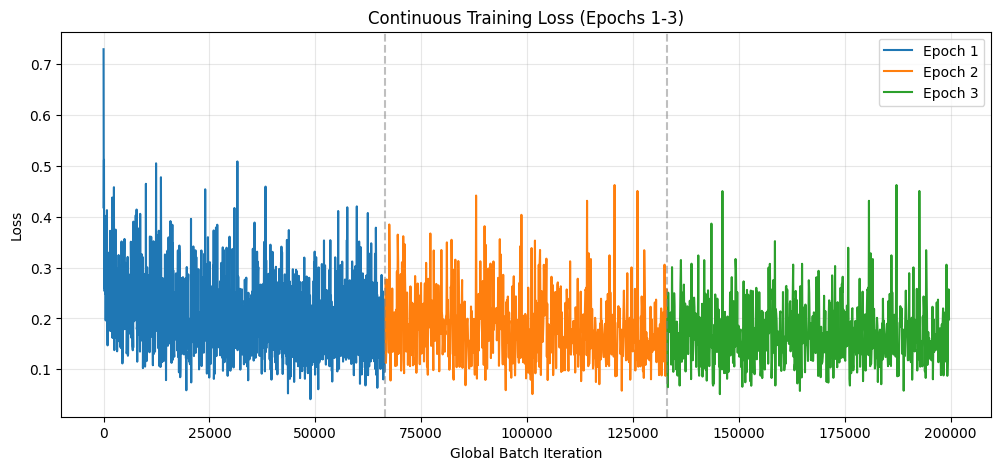

In [44]:
plt.figure(figsize=(12, 5))
total_batches = 66565

for epoch in [1, 2, 3]:
    b, l = data[epoch]
    # Offset the x-axis so Epoch 2 starts after Epoch 1
    x_offset = np.array(b) + (total_batches * (epoch - 1))
    plt.plot(x_offset, l, label=f'Epoch {epoch}')

plt.axvline(x=total_batches, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=total_batches*2, color='gray', linestyle='--', alpha=0.5)
plt.title("Continuous Training Loss (Epochs 1-3)")
plt.xlabel("Global Batch Iteration")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

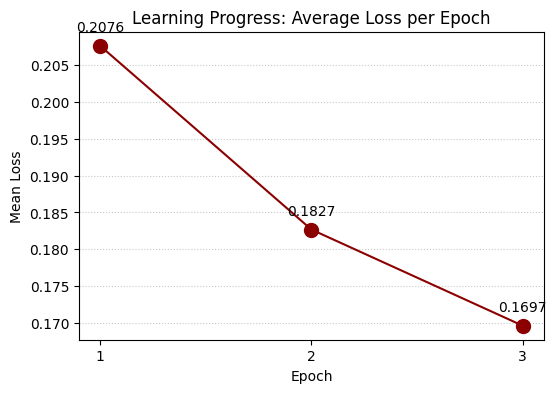

In [45]:
# Calculate averages
averages = [np.mean(data[i][1]) for i in [1, 2, 3]]
epochs = [1, 2, 3]

plt.figure(figsize=(6, 4))
plt.plot(epochs, averages, marker='o', markersize=10, linestyle='-', color='darkred')

# Add labels to the dots
for i, txt in enumerate(averages):
    plt.annotate(f'{txt:.4f}', (epochs[i], averages[i]), textcoords="offset points", xytext=(0,10), ha='center')

plt.title("Learning Progress: Average Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Mean Loss")
plt.xticks([1, 2, 3])
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.show()

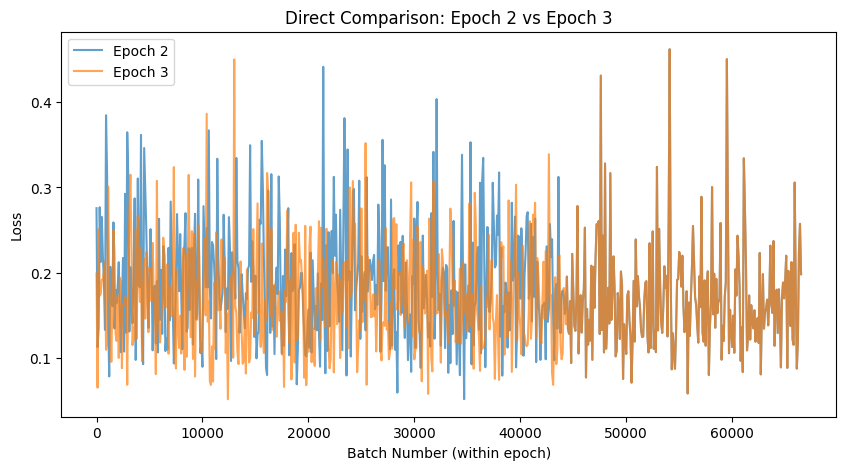

In [46]:
plt.figure(figsize=(10, 5))
plt.plot(data[2][0], data[2][1], label='Epoch 2', alpha=0.7)
plt.plot(data[3][0], data[3][1], label='Epoch 3', alpha=0.7)
plt.title("Direct Comparison: Epoch 2 vs Epoch 3")
plt.xlabel("Batch Number (within epoch)")
plt.ylabel("Loss")
plt.legend()
plt.show()

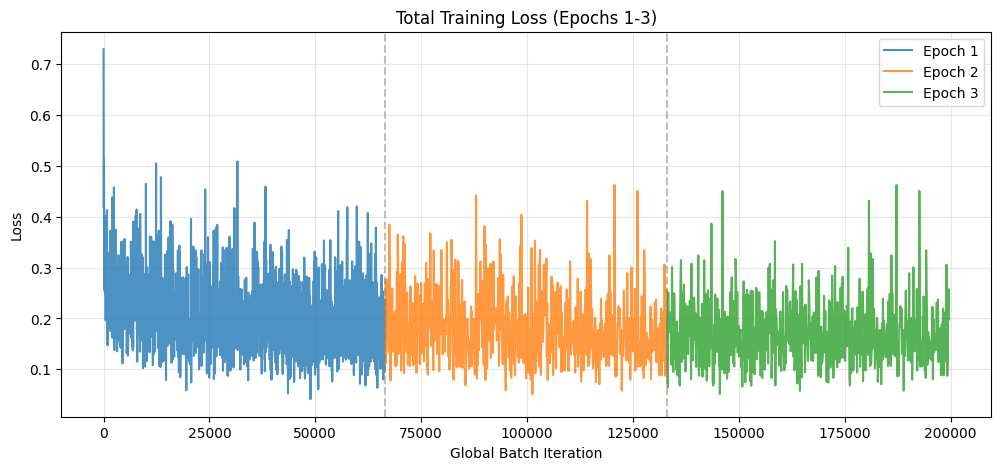

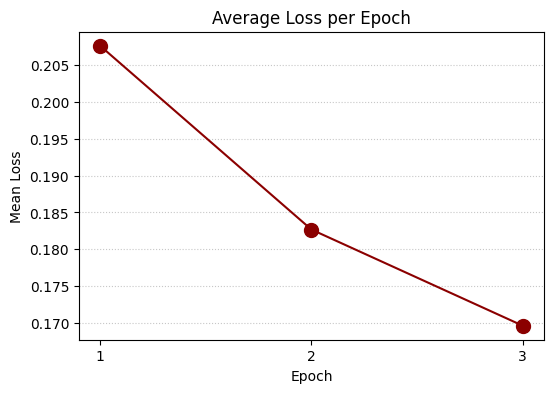

In [47]:
import os
import matplotlib.pyplot as plt

# 1. Create the output folder
output_folder = "training_plots"
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# --- PLOT 1: Total Continuous Loss ---
plt.figure(figsize=(12, 5))
total_batches = 66565
for epoch in [1, 2, 3]:
    b, l = data[epoch]
    x_offset = np.array(b) + (total_batches * (epoch - 1))
    plt.plot(x_offset, l, label=f'Epoch {epoch}', alpha=0.8)

plt.axvline(x=total_batches, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=total_batches*2, color='gray', linestyle='--', alpha=0.5)
plt.title("Total Training Loss (Epochs 1-3)")
plt.xlabel("Global Batch Iteration")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f"{output_folder}/total_loss_continuous.png", dpi=300, bbox_inches='tight')
plt.show()

# --- PLOT 2: Average Loss per Epoch ---
averages = [np.mean(data[i][1]) for i in [1, 2, 3]]
plt.figure(figsize=(6, 4))
plt.plot([1, 2, 3], averages, marker='o', markersize=10, color='darkred')
plt.title("Average Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Mean Loss")
plt.xticks([1, 2, 3])
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.savefig(f"{output_folder}/average_loss_per_epoch.png", dpi=300, bbox_inches='tight')
plt.show()

# --- PLOT 3 & 4: Individual Epoch Snapshots ---
for epoch in [1, 2, 3]:
    plt.figure(figsize=(8, 4))
    plt.plot(data[epoch][0], data[epoch][1], color='teal')
    plt.title(f"Training Loss: Epoch {epoch}")
    plt.xlabel("Batch Number")
    plt.ylabel("Loss")
    plt.savefig(f"{output_folder}/epoch_{epoch}_detail.png", dpi=300)
    plt.close() # Close to save memory

In [49]:
import os
print("Current Directory:", os.getcwd())
print("Files/Folders here:", os.listdir())

Current Directory: /Users/apple/pytorch-lab/DoubleB/train_data
Files/Folders here: ['feature_distributions', 'ntuple_merged_76.root', 'ntuple_merged_21.root', 'ntuple_merged_37.root', 'ntuple_merged_60.root', 'ntuple_merged_17.root', 'ntuple_merged_40.root', 'ntuple_merged_56.root', 'ntuple_merged_83.root', 'Untitled1.ipynb', 'ntuple_merged_82.root', '.DS_Store', 'train_root_doubleb.ipynb', 'ntuple_merged_57.root', 'ntuple_merged_41.root', 'ntuple_merged_16.root', 'ntuple_merged_61.root', 'ntuple_merged_36.root', 'ntuple_merged_20.root', 'ntuple_merged_77.root', 'DoubleB_full_particle_transformer.ipynb', 'ntuple_merged_11.root', 'Untitled.ipynb', 'ntuple_merged_46.root', 'Final_Results', 'ntuple_merged_50.root', 'ntuple_merged_85.root', 'distribution_plots', 'ntuple_merged_70.root', 'ntuple_merged_27.root', 'ntuple_merged_31.root', 'ntuple_merged_89.root', 'ntuple_merged_66.root', 'ntuple_merged_88.root', 'ntuple_merged_67.root', 'ntuple_merged_30.root', 'ntuple_merged_26.root', 'ntupl

In [51]:
import os

# This searches your entire current project folder for the file
for root, dirs, files in os.walk("."):
    for file in files:
        if file == "model_outputs":
            print(f"FOUND IT! The actual path is: {os.path.join(root, file)}")

In [52]:
import numpy as np
import os

# Try searching for it relative to your current location
possible_path = "../model_outputs/bdt_results.npz" 

if os.path.exists(possible_path):
    bdt_data = np.load(possible_path)
    print("Success! Found it one level up.")
else:
    # If that fails, try the absolute path based on your 'pwd' output
    absolute_path = "/Users/apple/pytorch-lab/model_outputs/bdt_results.npz"
    if os.path.exists(absolute_path):
        bdt_data = np.load(absolute_path)
        print("Success! Found it in the main pytorch-lab folder.")
    else:
        print("Still not found. Please check if it's inside 'Final_Results' or the root 'pytorch-lab' folder.")

Still not found. Please check if it's inside 'Final_Results' or the root 'pytorch-lab' folder.


In [63]:
db

tensor([-0.5665, -0.9738,  0.1275,  0.3461, -0.8001,  0.9133,  0.8397,  0.9748,
         0.9361,  0.8500,  0.0747, -0.9503,  0.8968, -0.7896, -0.6858,  0.5894,
        -0.9750,  0.6698,  0.5362, -0.7692, -0.7754,  0.9662,  0.1059,  0.4426,
        -0.8602, -0.5311, -0.9483, -0.9453,  0.6824,  0.9030, -0.8918,  0.1757,
        -0.4653,  0.8142, -0.3401, -0.9669, -0.8435, -0.6501,  0.8937, -0.3453,
         0.5257,  0.9088, -0.9347,  0.2511,  0.8432, -0.7961,  0.8679, -0.8721,
        -0.4640,  0.8991, -0.9385, -0.9762, -0.7765,  0.9415, -0.8938])

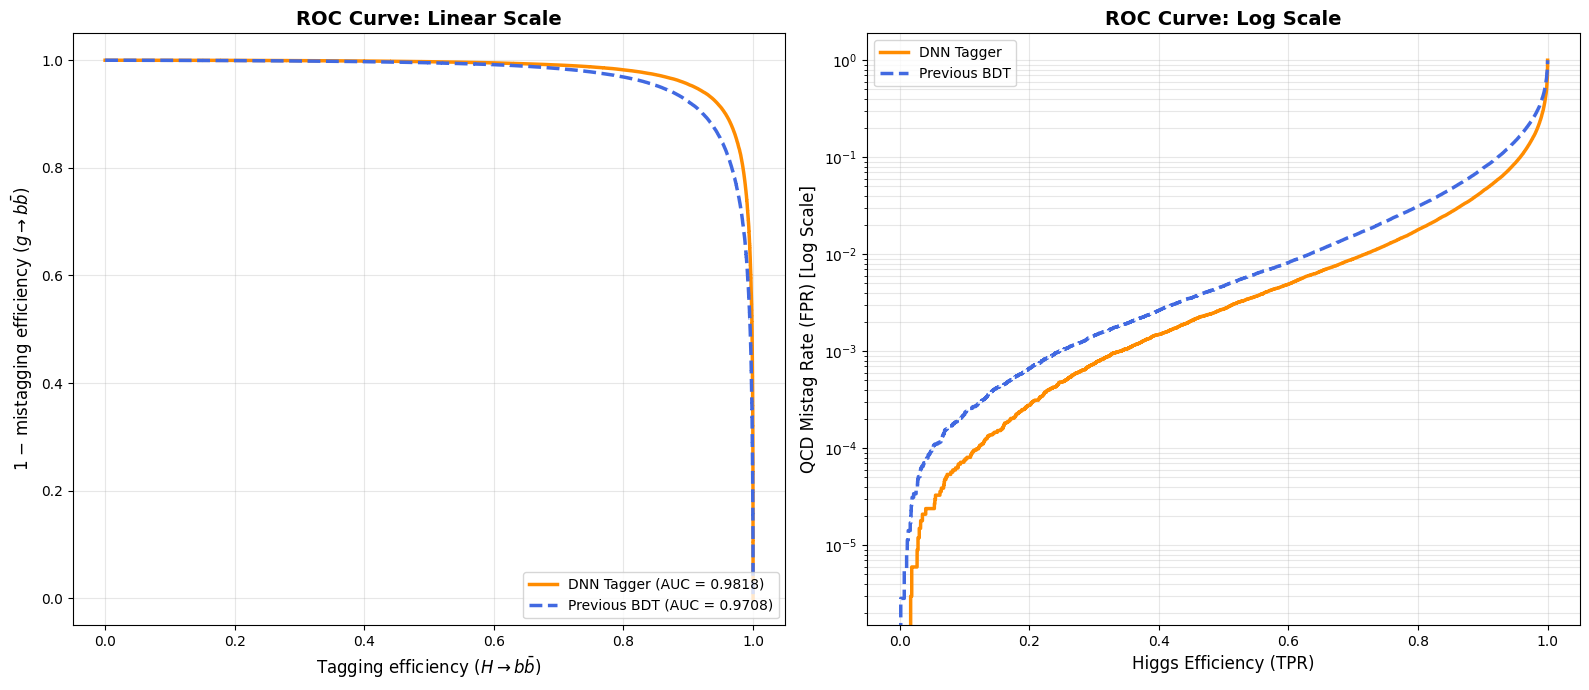

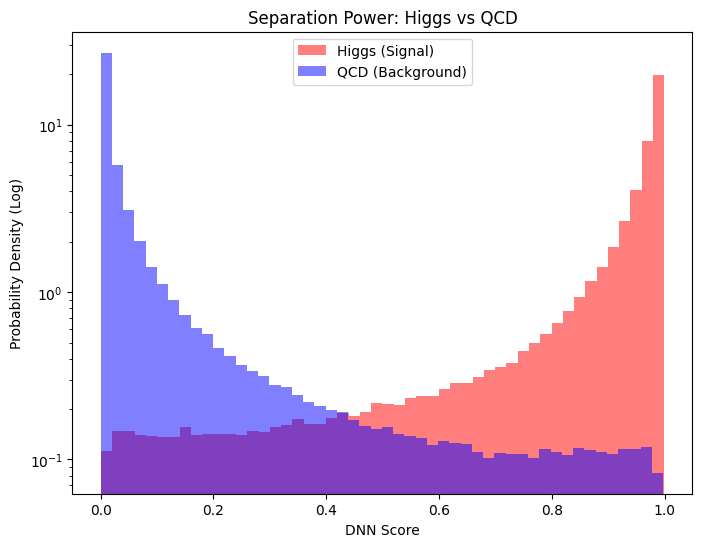

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# --- 1. Use the Corrected DNN Results ---
# Ensure we are using the binary y_true and y_score we just extracted
y_true_dnn = y_true_clean
y_score_dnn = y_score_clean

# Calculate DNN Metrics
fpr_dnn, tpr_dnn, _ = roc_curve(y_true_dnn, y_score_dnn)
auc_dnn = auc(fpr_dnn, tpr_dnn)

# --- 2. Load and Filter BDT Results ---
bdt_data = np.load('model_outputs/bdt_results.npz')
y_t_bdt = bdt_data['y_true'].flatten()
y_s_bdt = bdt_data['y_score'].flatten()

# Filter BDT for 0 and 1 only (removing the -1/background classes if any)
valid_mask_bdt = (y_t_bdt == 0) | (y_t_bdt == 1)
y_t_bdt_filt = y_t_bdt[valid_mask_bdt]
y_s_bdt_filt = y_s_bdt[valid_mask_bdt]

fpr_bdt, tpr_bdt, _ = roc_curve(y_t_bdt_filt, y_s_bdt_filt)
auc_bdt = auc(fpr_bdt, tpr_bdt)

# --- 3. Final Comparison Plot (Linear and Log Scale) ---
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Subplot 1: Linear ROC
ax[0].plot( tpr_dnn,1-fpr_dnn, color='darkorange', lw=2.5, label=f'DNN Tagger (AUC = {auc_dnn:.4f})')
ax[0].plot( tpr_bdt,1-fpr_bdt, color='royalblue', lw=2.5, linestyle='--', label=f'Previous BDT (AUC = {auc_bdt:.4f})')

ax[0].set_xlabel('Tagging efficiency ($H \\rightarrow b\\bar{b}$)', fontsize=12)
ax[0].set_ylabel('1 $-$ mistagging efficiency ($g \\rightarrow b\\bar{b}$)', fontsize=12)
ax[0].set_title('ROC Curve: Linear Scale', fontsize=14, fontweight='bold')
ax[0].legend(loc="lower right")
ax[0].grid(True, alpha=0.3)

# Subplot 2: Log Scale ROC (Standard in HEP to see low mistag rates)
# We plot 1/FPR (Rejection) vs Efficiency or just Log(FPR)
ax[1].plot(tpr_dnn, fpr_dnn, color='darkorange', lw=2.5, label=f'DNN Tagger')
ax[1].plot(tpr_bdt, fpr_bdt, color='royalblue', lw=2.5, linestyle='--', label=f'Previous BDT')
ax[1].set_yscale('log')
ax[1].set_xlabel('Higgs Efficiency (TPR)', fontsize=12)
ax[1].set_ylabel('QCD Mistag Rate (FPR) [Log Scale]', fontsize=12)
ax[1].set_title('ROC Curve: Log Scale', fontsize=14, fontweight='bold')
ax[1].legend(loc="upper left")
ax[1].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.savefig("training_plots/Final_ROC_Comparison.png", dpi=300)
plt.show()

# --- 4. Score Distribution Plot ---
plt.figure(figsize=(8, 6))
plt.hist(y_score_dnn[y_true_dnn == 1], bins=50, alpha=0.5, label='Higgs (Signal)', color='red', density=True)
plt.hist(y_score_dnn[y_true_dnn == 0], bins=50, alpha=0.5, label='QCD (Background)', color='blue', density=True)
plt.yscale('log')
plt.xlabel('DNN Score')
plt.ylabel('Probability Density (Log)')
plt.title('Separation Power: Higgs vs QCD')
plt.legend()
plt.show()

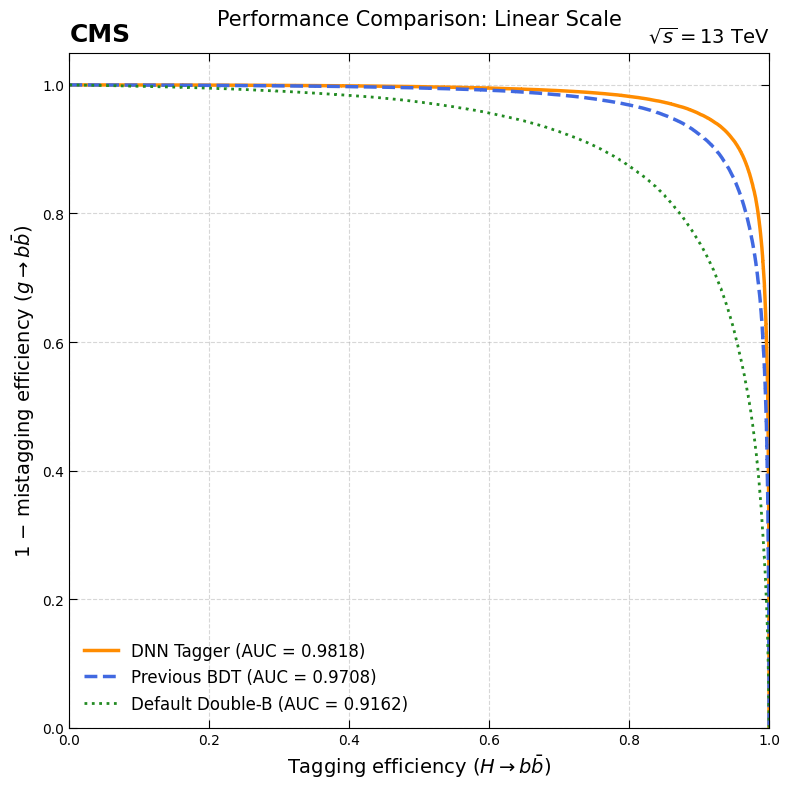

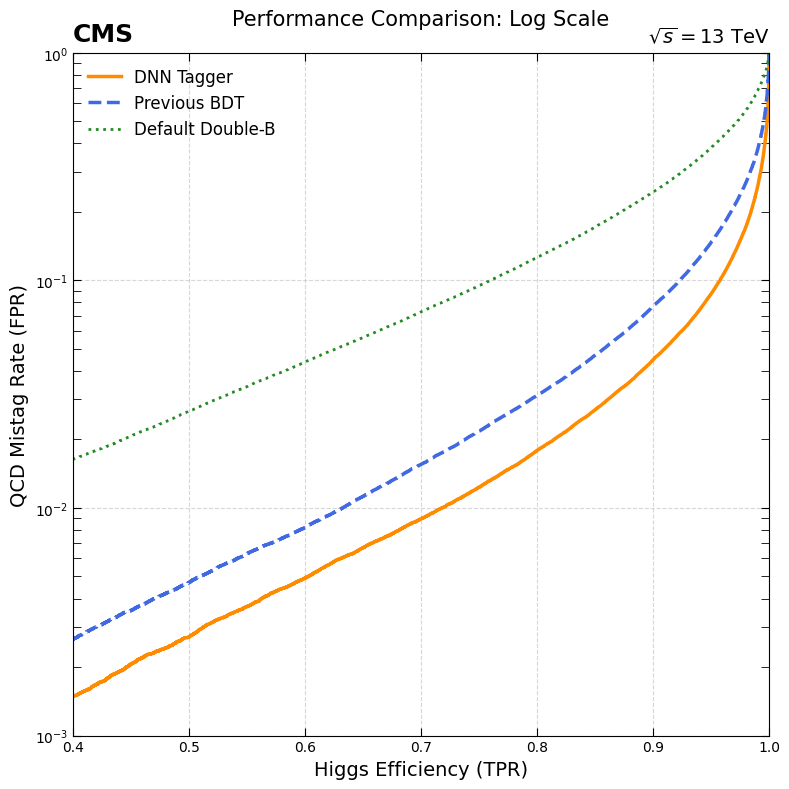

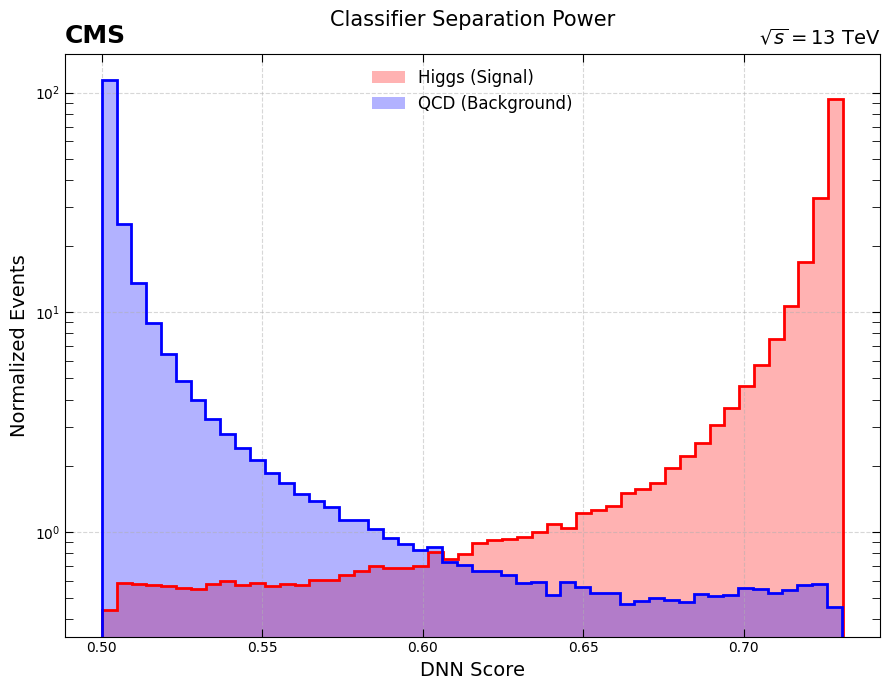

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# --- 1. Calculate Metrics ---
fpr_dnn, tpr_dnn, _ = roc_curve(y_true_dnn, y_score_dnn)
auc_dnn = auc(fpr_dnn, tpr_dnn)

fpr_bdt, tpr_bdt, _ = roc_curve(y_t_bdt_filt, y_s_bdt_filt)
auc_bdt = auc(fpr_bdt, tpr_bdt)

fpr_db, tpr_db, _ = roc_curve(y_true_dnn, db_np)
auc_db = auc(fpr_db, tpr_db)

# --- CMS Styling Helper ---
def apply_cms_style(ax, title):
    # CMS Branding
    ax.text(0.0, 1.01, "CMS", transform=ax.transAxes, fontsize=18, fontweight='bold', va='bottom')
   
    ax.text(1.0, 1.01, r"$\sqrt{s} = 13$ TeV", transform=ax.transAxes, fontsize=14, ha='right', va='bottom')
    
    ax.set_title(title, fontsize=15, pad=20)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(which='both', direction='in', top=True, right=True, length=6)

# --- Plot 1: Linear ROC ---
plt.figure(figsize=(8, 8))
plt.plot(tpr_dnn, 1-fpr_dnn, color='darkorange', lw=2.5, label=f'DNN Tagger (AUC = {auc_dnn:.4f})')
plt.plot(tpr_bdt, 1-fpr_bdt, color='royalblue', lw=2.5, linestyle='--', label=f'Previous BDT (AUC = {auc_bdt:.4f})')
plt.plot(tpr_db, 1-fpr_db, color='forestgreen', lw=2.0, linestyle=':', label=f'Default Double-B (AUC = {auc_db:.4f})')

plt.xlabel('Tagging efficiency ($H \\rightarrow b\\bar{b}$)', fontsize=14)
plt.ylabel('1 $-$ mistagging efficiency ($g \\rightarrow b\\bar{b}$)', fontsize=14)
apply_cms_style(plt.gca(), "Performance Comparison: Linear Scale")
plt.legend(loc="lower left", frameon=False, fontsize=12)
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig("training_plots/Final_ROC_Comparison.png", dpi=300)
plt.show()

# --- Plot 2: Log Scale ROC ---
plt.figure(figsize=(8, 8))
plt.plot(tpr_dnn, fpr_dnn, color='darkorange', lw=2.5, label='DNN Tagger')
plt.plot(tpr_bdt, fpr_bdt, color='royalblue', lw=2.5, linestyle='--', label='Previous BDT')
plt.plot(tpr_db, fpr_db, color='forestgreen', lw=2.0, linestyle=':', label='Default Double-B')

plt.yscale('log')
plt.xlabel('Higgs Efficiency (TPR)', fontsize=14)
plt.ylabel('QCD Mistag Rate (FPR)', fontsize=14)
apply_cms_style(plt.gca(), "Performance Comparison: Log Scale")
plt.legend(loc="upper left", frameon=False, fontsize=12)
plt.xlim(0.4, 1.0) 
plt.ylim(1e-3, 1)
plt.tight_layout()
plt.savefig("training_plots/Final_ROC_Comparisonlogscale.png", dpi=300)
plt.show()

# --- Plot 3: Score Distribution ---
plt.figure(figsize=(9, 7))
plt.hist(y_score_dnn[y_true_dnn == 1], bins=50, alpha=0.3, label='Higgs (Signal)', color='red', density=True, histtype='stepfilled')
plt.hist(y_score_dnn[y_true_dnn == 1], bins=50, color='red', density=True, histtype='step', lw=2)
plt.hist(y_score_dnn[y_true_dnn == 0], bins=50, alpha=0.3, label='QCD (Background)', color='blue', density=True, histtype='stepfilled')
plt.hist(y_score_dnn[y_true_dnn == 0], bins=50, color='blue', density=True, histtype='step', lw=2)

plt.yscale('log')
plt.xlabel('DNN Score', fontsize=14)
plt.ylabel('Normalized Events', fontsize=14)
apply_cms_style(plt.gca(), "Classifier Separation Power")
plt.legend(loc='upper center', frameon=False, fontsize=12)
plt.tight_layout()
plt.show()

In [65]:
y_true_list = []
y_score_list = []
db_list = [] 

model.to('cpu') # Safety for MPS errors
model.eval()

with torch.no_grad():
    for data_batch in test_loader:
        # 1. Unpack all needed variables from the batch
        # Assuming order: pf, tk, sv, jet, labels, pt, mass, doubleb
        pf, tk, sv, jet = [x.to('cpu') for x in data_batch[:4]]
        labels = data_batch[4]
        doubleb = data_batch[7] # fj_doubleb
        
        # 2. Run model
        outputs = model(pf, tk, sv, jet)
        probs = torch.sigmoid(outputs).numpy()
        
        # 3. Append to lists (Crucial: append labels and db every time!)
        y_true_list.extend(labels.numpy())
        y_score_list.extend(probs)
        db_list.extend(doubleb.numpy()) 

# 4. Convert to final numpy arrays
y_true_dnn = np.array(y_true_list)
y_score_dnn = np.array(y_score_list)
db_np = np.array(db_list)

print(f"Lengths matched: y_true={len(y_true_dnn)}, db={len(db_np)}")

Lengths matched: y_true=519159, db=519159
